In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import ruptures as rpt
import multiprocessing
from concurrent import futures
from tqdm import tqdm

import sys

sys.path.append("../..")

from src import IOFunctions
from IPython.display import display, clear_output

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=True)

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

/tmp/ipykernel_2450571/948331448.py:20: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=True)


In [2]:
dye_data_folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/FRET/20pM_HJ_200mM_MgCl2/'

In [3]:
all_h5_files = H_F.file_search(dye_data_folder, ".h5", "")

# Exclude any previously-saved changepoint files so we don't re-process them
loc_files = [f for f in all_h5_files if not f.endswith('_colourchangepoint.h5')]
changepoint_files = [f for f in all_h5_files if f.endswith('_colourchangepoint.h5')]
print(f"Found {len(loc_files)} analysis H5 files to process")
for i, f in enumerate(loc_files):
    out_path = os.path.splitext(f)[0] + '_colourchangepoint.h5'
    status = "EXISTS" if os.path.exists(out_path) else "pending"
    print(f"  [{i:02d}] {os.path.basename(f)}  [{status}]")

Found 25 analysis H5 files to process
  [00] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.h5  [EXISTS]
  [01] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_001.h5  [EXISTS]
  [02] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_002.h5  [EXISTS]
  [03] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_003.h5  [EXISTS]
  [04] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_004.h5  [EXISTS]
  [05] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_000.h5  [EXISTS]
  [06] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_001.h5  [EXISTS]
  [07] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_002.h5  [EXISTS]
  [08] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_003.h5  [EXISTS]
  [09] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposur

In [4]:
tiff_files = H_F.file_search(dye_data_folder, ".tif", "")
print(f"Found {len(tiff_files)} tiff files")
for i, f in enumerate(tiff_files):
    print(f"  [{i}]: {os.path.basename(f)}")

Found 25 tiff files
  [0]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.ome.tif
  [1]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_001.ome.tif
  [2]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_002.ome.tif
  [3]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_003.ome.tif
  [4]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_004.ome.tif
  [5]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_000.ome.tif
  [6]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_001.ome.tif
  [7]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_002.ome.tif
  [8]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_003.ome.tif
  [9]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_004.ome.tif
  [10]: 20pM_HJ_20p561_568lp_D

In [5]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r488-561-t1-25x36"
dichroic_mirror_all = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_red_filter = "semrock-blp01-635r"

longpass_filter = "semrock-blp01-568r"
filters = [dichroic_mirror, longpass_filter,shortpass_filter]
dye = "Cy3"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy3 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

dye = "Cy5"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy5 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

print(f"Cy3 pixel efficiencies (B, G, R): {dye_pixel_efficiency_Cy3}")
print(f"Cy5 pixel efficiencies (B, G, R): {dye_pixel_efficiency_Cy5}")

Cy3 pixel efficiencies (B, G, R): [0.02105954 0.3841594  0.59478107]
Cy5 pixel efficiencies (B, G, R): [0.0597494  0.18662932 0.75362128]


In [6]:
def load_changepoint_analysis(changepoint_h5_path):
    """Load all tables from a _colourchangepoint.h5 file.

    Convenience reader for the plotting notebook.  Returns the three tables
    written by save_changepoint_results() so you can immediately plot traces,
    segment means, or aggregate statistics without recomputing anything.

    Usage example::

        df_data, cp_df, seg_df = load_changepoint_analysis(path)

        # plot segment means for one punctum
        pid = 42
        sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
        segs = seg_df[seg_df['puncta_id'] == pid]
        cps  = cp_df[cp_df['puncta_id'] == pid]

        t = sub['frame'].values * exposure_time
        plt.scatter(t, sub['A_R'], s=4, c='red')
        for _, row in segs.iterrows():
            plt.hlines(row['A_R_mean'],
                       row['frame_start'] * exposure_time,
                       row['frame_end']   * exposure_time,
                       colors='darkred', lw=2)
        for _, cp in cps.iterrows():
            plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')

    Args:
        changepoint_h5_path (str): Path to a *_colourchangepoint.h5 file.

    Returns:
        tuple:
            df_data (pd.DataFrame): Filtered localisation data.
            cp_df   (pd.DataFrame): Change-points table.
            seg_df  (pd.DataFrame): Segment-statistics table.
    """
    df_data = pd.read_hdf(changepoint_h5_path, key='data')
    cp_df   = pd.read_hdf(changepoint_h5_path, key='changepoints')
    seg_df  = pd.read_hdf(changepoint_h5_path, key='segments')
    return df_data, cp_df, seg_df


In [7]:
[df_data, cp_df, seg_df] = load_changepoint_analysis(changepoint_files[0])

In [8]:
cp_puncta_ids = df_data['puncta_id'].unique()
cp_puncta_ids = np.sort(cp_puncta_ids)

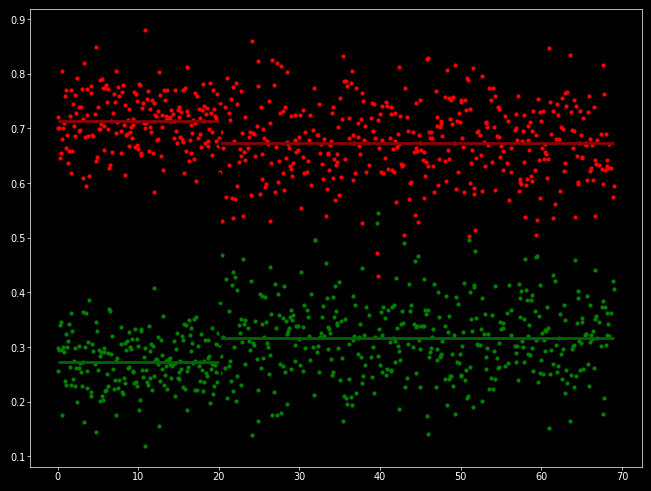

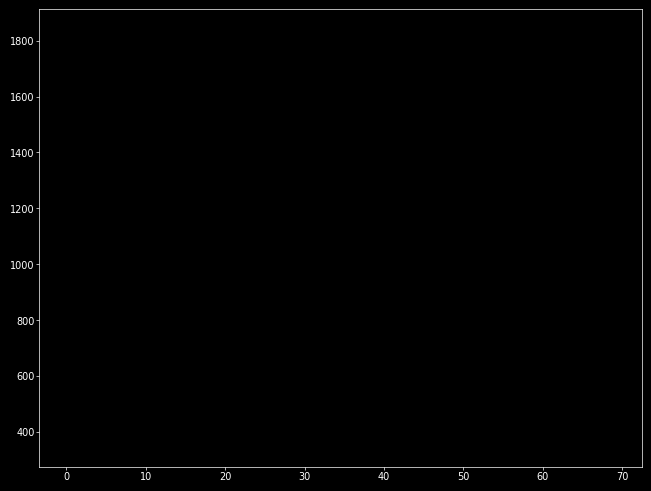

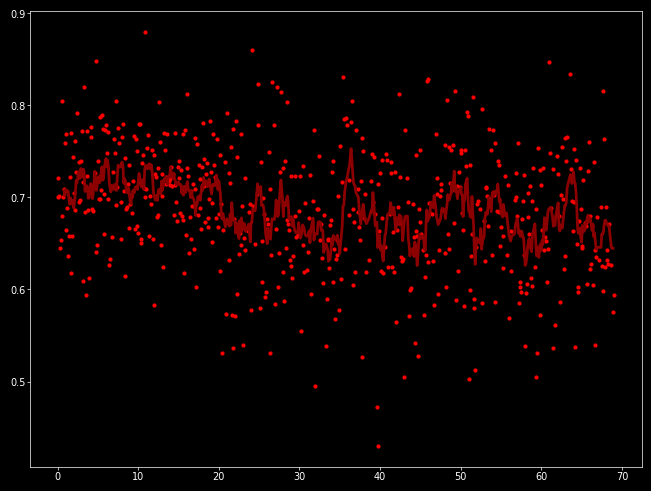

In [9]:
# plot segment means for one punctum, 9, 14,15,20
exposure_time = 0.1
pid = cp_puncta_ids[15]
sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
segs = seg_df[seg_df['puncta_id'] == pid]
cps  = cp_df[cp_df['puncta_id'] == pid]

t = sub['frame'].values * exposure_time
plt.scatter(t, sub['A_R'], s=4, c='red')
for _, row in segs.iterrows():
    plt.hlines(row['A_R_mean'],
               row['frame_start'] * exposure_time,
               row['frame_end']   * exposure_time,
               colors='darkred', lw=2)
plt.scatter(t, sub['A_G'], s=4, c='green')
for _, row in segs.iterrows():
    plt.hlines(row['A_G_mean'],
               row['frame_start'] * exposure_time,
               row['frame_end']   * exposure_time,
               colors='darkgreen', lw=2)
for _, cp in cps.iterrows():
    plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
plt.show()

plt.scatter(t, sub['photons'], s=4, c='black')
for _, cp in cps.iterrows():
    plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
plt.show()


window_size = 10

# Create normalized window
window = np.ones(window_size) / window_size
plt.scatter(t, sub['A_R'], s=4, c='red')
smoothed_red = np.convolve(window,sub['A_R'],mode='valid')
plt.plot(t[8:-1],smoothed_red,lw=2,c='darkred')
plt.show()


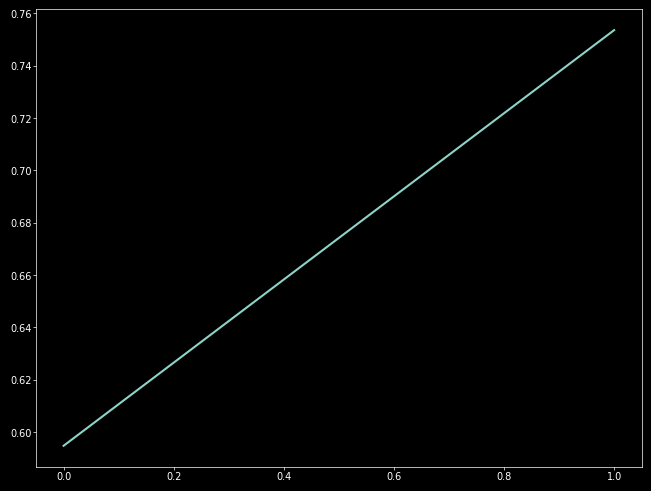

In [10]:
E_range = np.linspace(0,1,101)
R_range = dye_pixel_efficiency_Cy3[2]*(1-E_range) + dye_pixel_efficiency_Cy5[2]*(E_range)
plt.plot(E_range,R_range)

In [11]:
def RGB_to_E_Cy3Cy5_cp(segs):
    """Converts an RGB value to the ESTIMATED FRET efficiency


    Args:
        segs: pd.DataFrame: average values per changepoint for RGB,photons,etc

    Returns:
        E: array: FRET Estimated FRET efficiencies not including quantum yield losses
    """
    d = dye_pixel_efficiency_Cy3 - dye_pixel_efficiency_Cy5
    denom = np.dot(d,d)
    X = np.array([segs['A_B_mean'],segs['A_G_mean'],segs['A_R_mean']])
    X = X.T
    num = np.einsum('ij,j->i', X - dye_pixel_efficiency_Cy5, d)  # (X - B) dot d, per row
    alpha = num/denom
    
        # Compute residuals
    recon = alpha[:, None] * dye_pixel_efficiency_Cy3 + (1.0 - alpha)[:, None] * dye_pixel_efficiency_Cy5
    residuals = np.sum((X - recon) ** 2, axis=1)
    residuals
    return(alpha,residuals)

In [12]:
def RGB_to_E_Cy3Cy5_data(data):
    """Converts an RGB value to the ESTIMATED FRET efficiency


    Args:
        segs: pd.DataFrame: average values per changepoint for RGB,photons,etc

    Returns:
        E: array: FRET Estimated FRET efficiencies not including quantum yield losses
    """
    d = dye_pixel_efficiency_Cy3 - dye_pixel_efficiency_Cy5
    denom = np.dot(d,d)
    X = np.array([data['A_B'],data['A_G'],data['A_R']])
    X = X.T
    num = np.einsum('ij,j->i', X - dye_pixel_efficiency_Cy5, d)  # (X - B) dot d, per row
    alpha = num/denom
    
        # Compute residuals
    recon = alpha[:, None] * dye_pixel_efficiency_Cy3 + (1.0 - alpha)[:, None] * dye_pixel_efficiency_Cy5
    residuals = np.sum((X - recon) ** 2, axis=1)
    residuals
    return(alpha,residuals)

In [13]:
[E,residuals] = RGB_to_E_Cy3Cy5_cp(seg_df)

1122


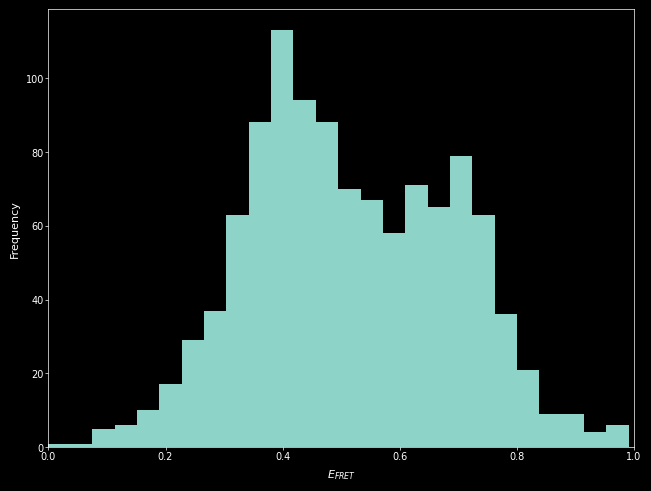

In [14]:
plt.hist(E,bins=np.histogram_bin_edges(E, 'sqrt'))
plt.xlabel('$E_{FRET}$')
plt.ylabel('Frequency')
plt.xlim([0,1])
print(seg_df.shape[0])

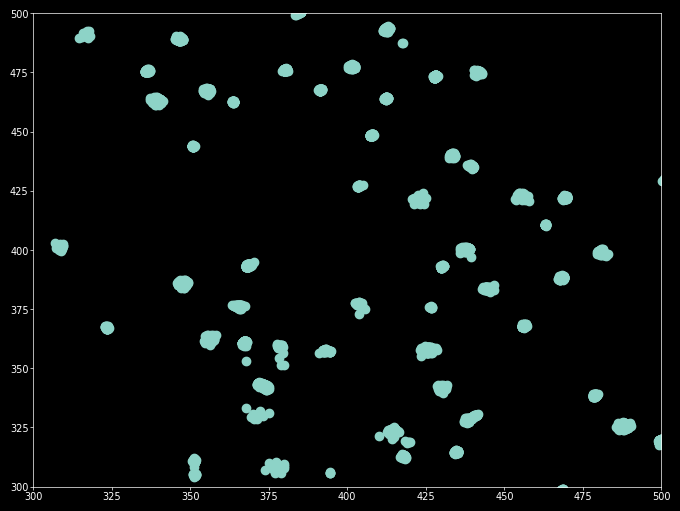

In [19]:
plt.scatter(df_data['xc'],df_data['yc'])
origin =400
ROI = 200 # pixel roi
x_begin = origin-ROI/2
x_end= origin + ROI/2

y_begin = origin-ROI/2
y_end= origin + ROI/2

plt.xlim([x_begin,x_end])
plt.ylim([y_begin,y_end])

ROI_true = (df_data['xc'] > x_begin)*(df_data['xc'] < x_end)*(df_data['yc'] > y_begin)*(df_data['yc'] < y_end)
ROI_df_data = df_data[ROI_true]

In [20]:
ROI_puncta_ID = np.sort(ROI_df_data['puncta_id'].unique())

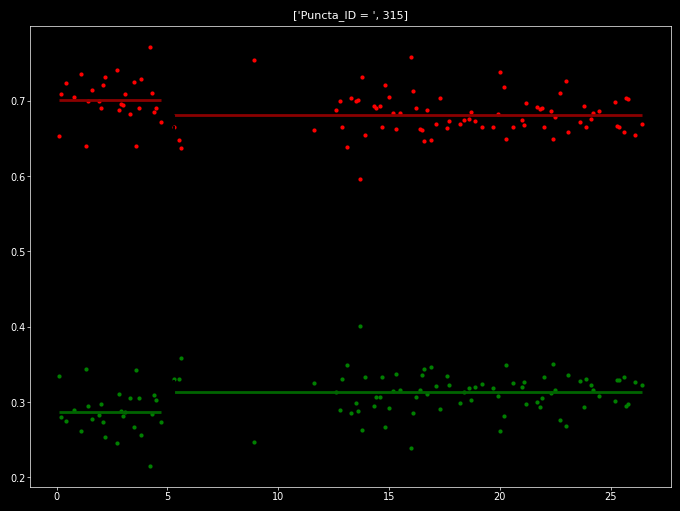

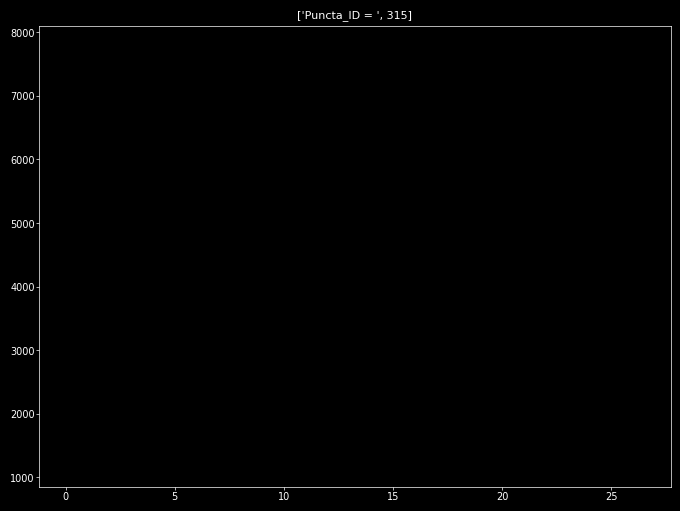

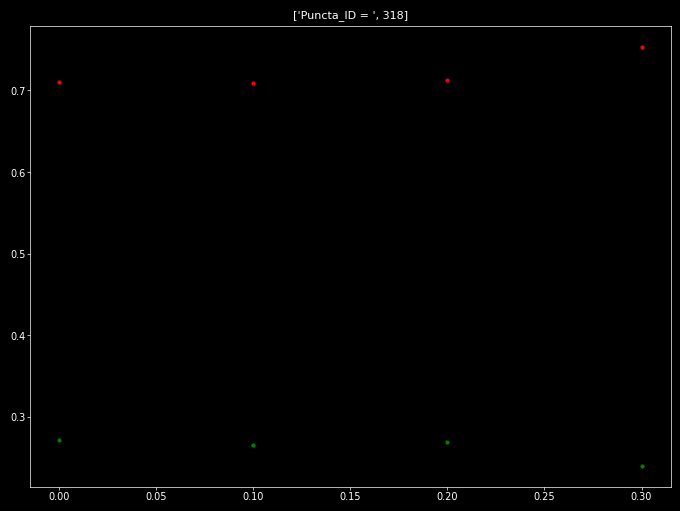

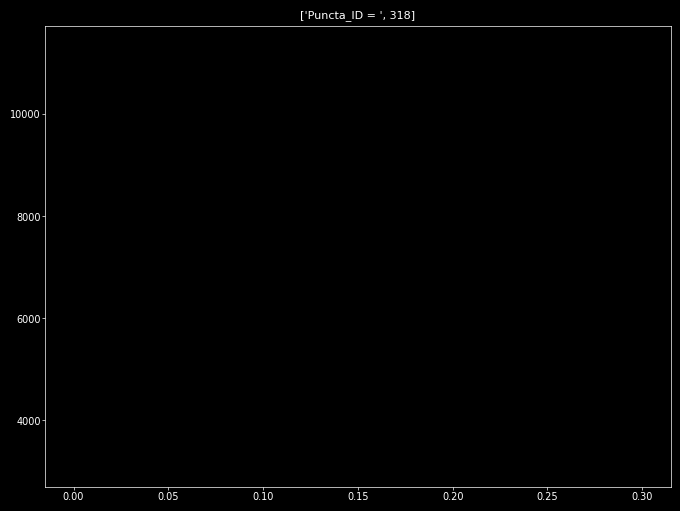

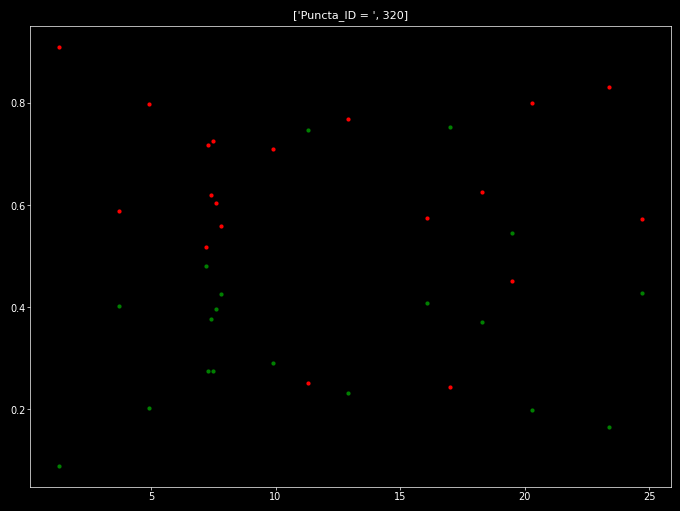

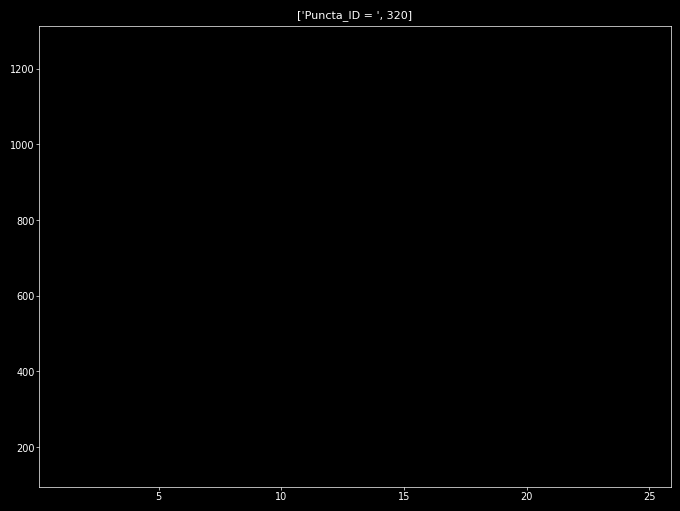

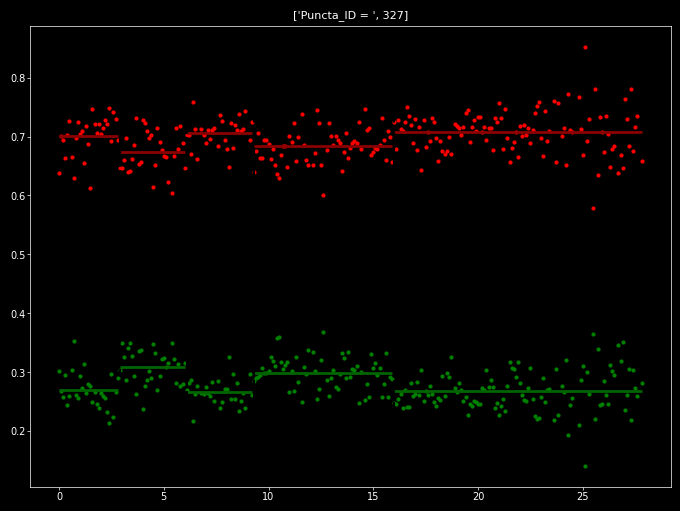

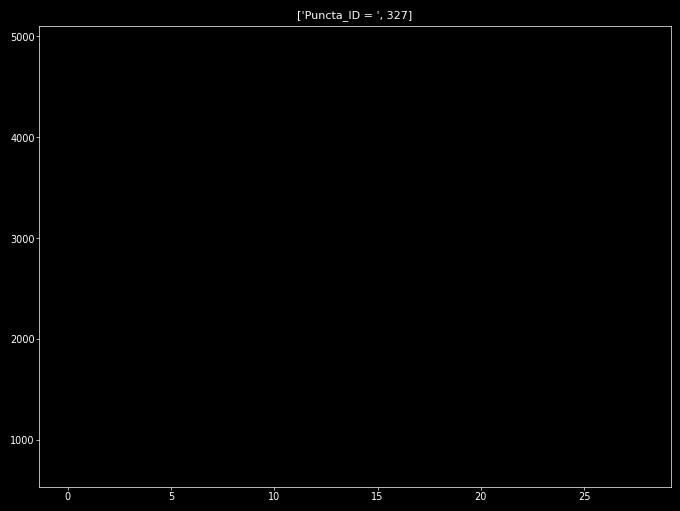

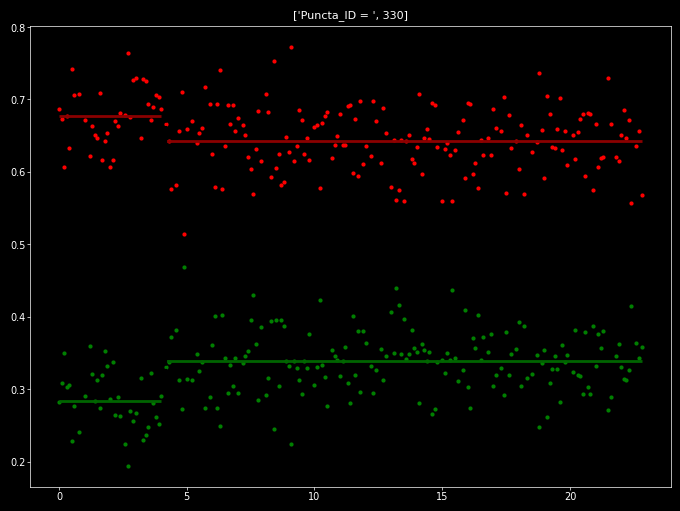

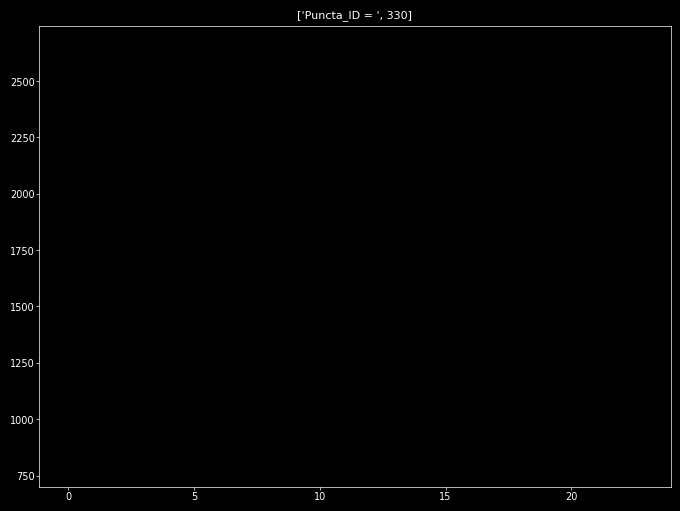

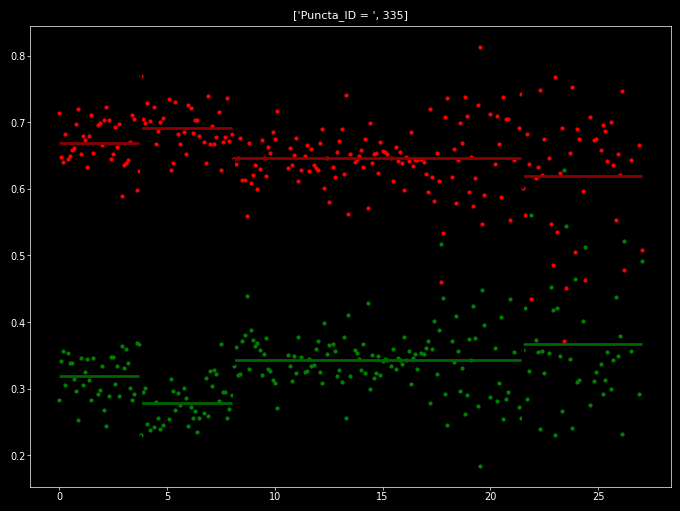

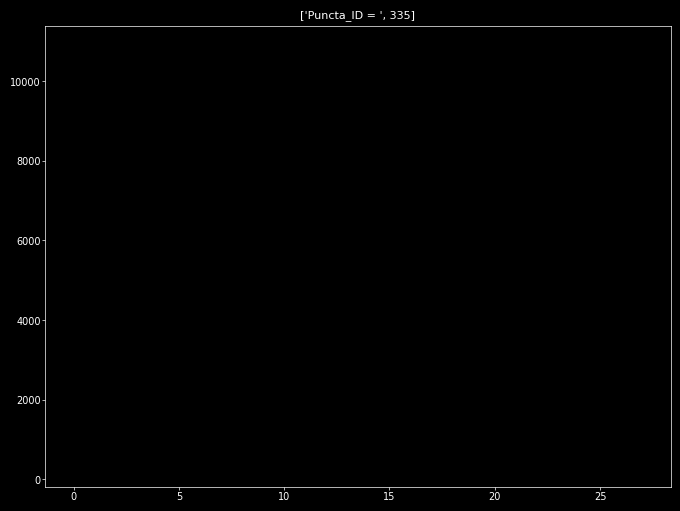

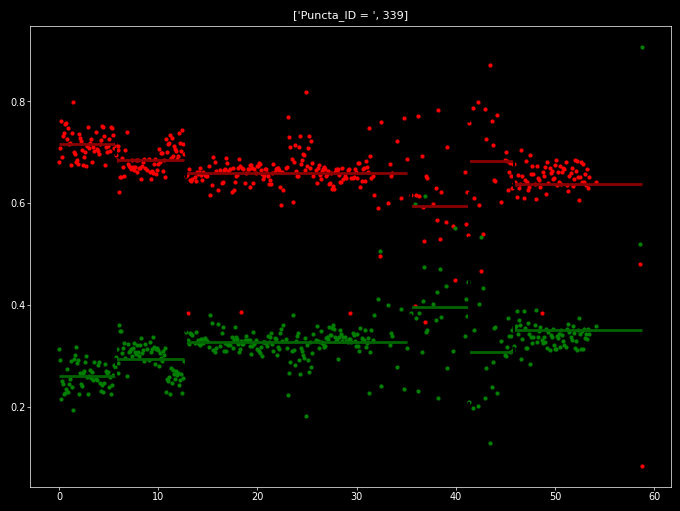

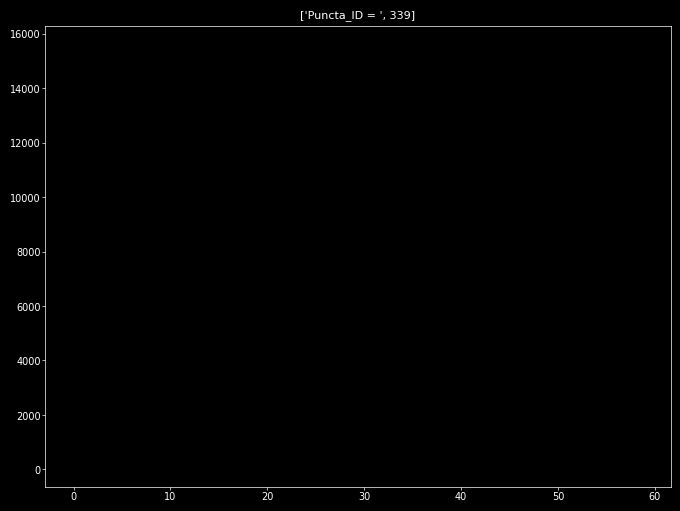

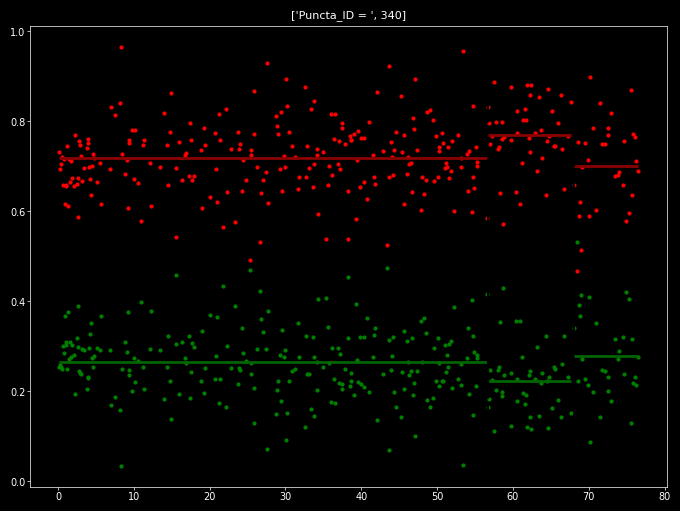

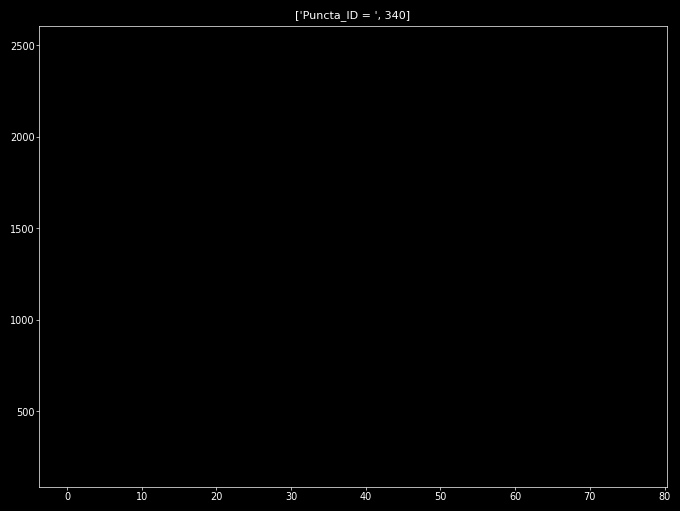

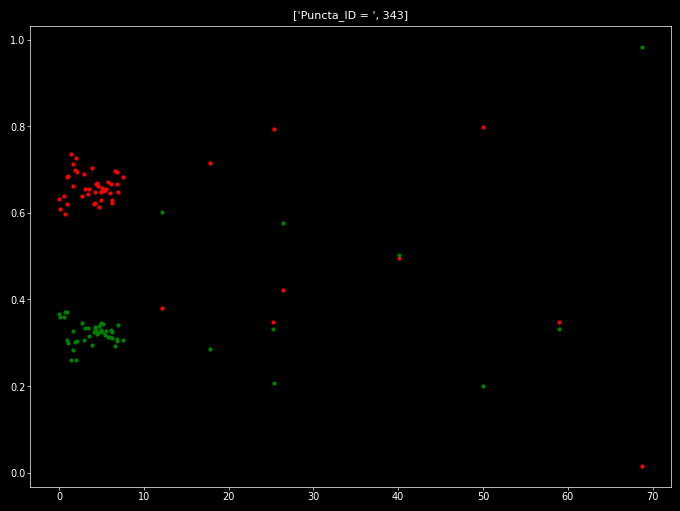

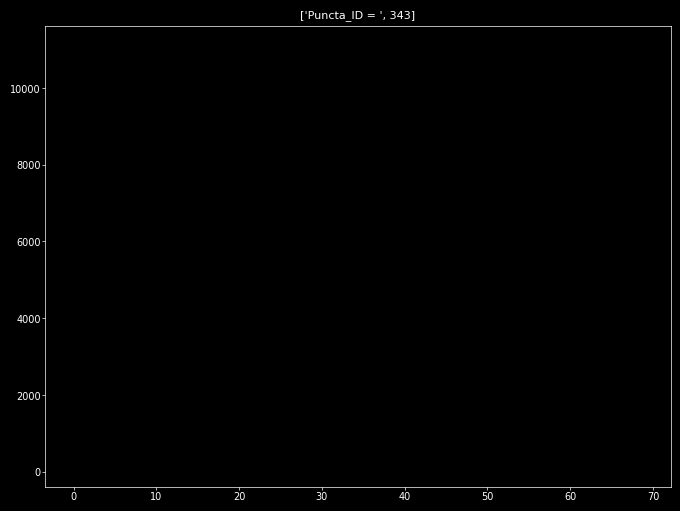

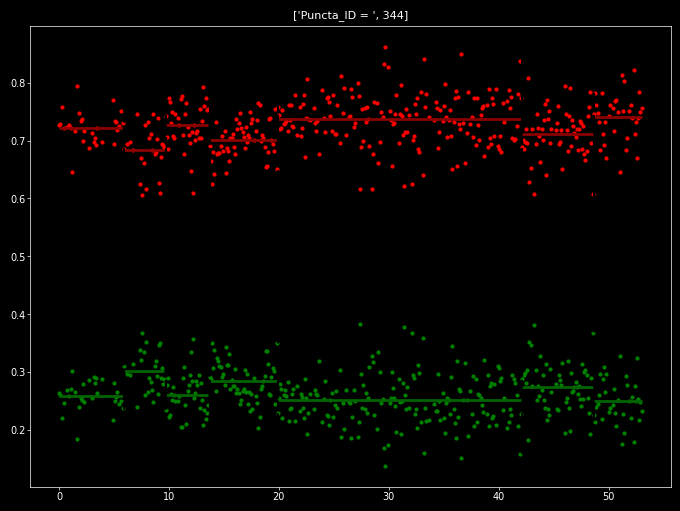

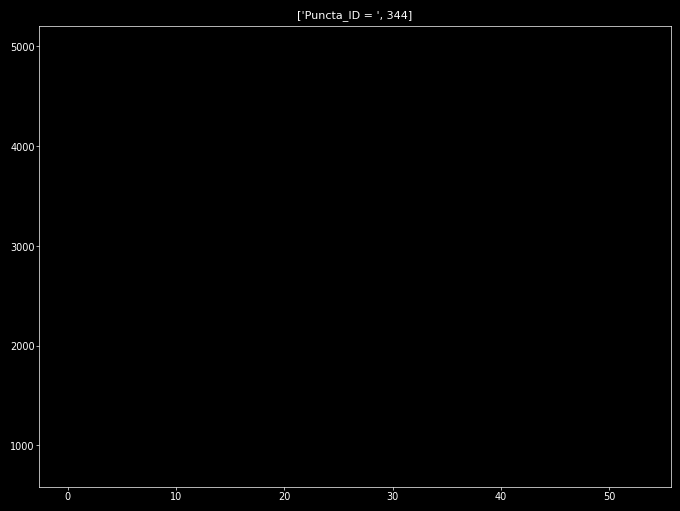

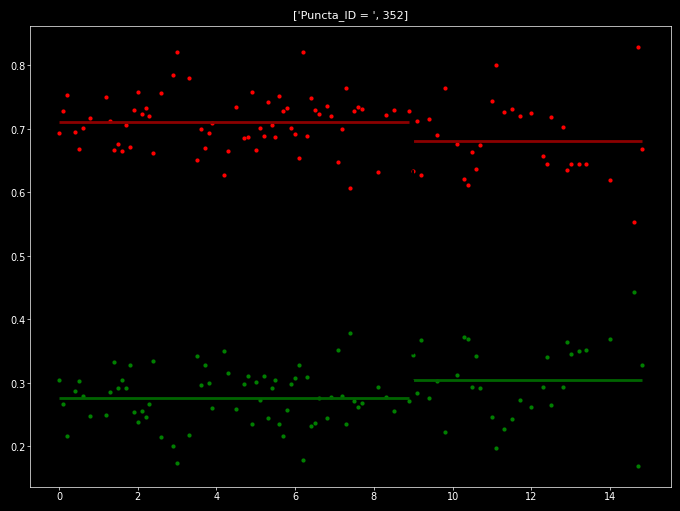

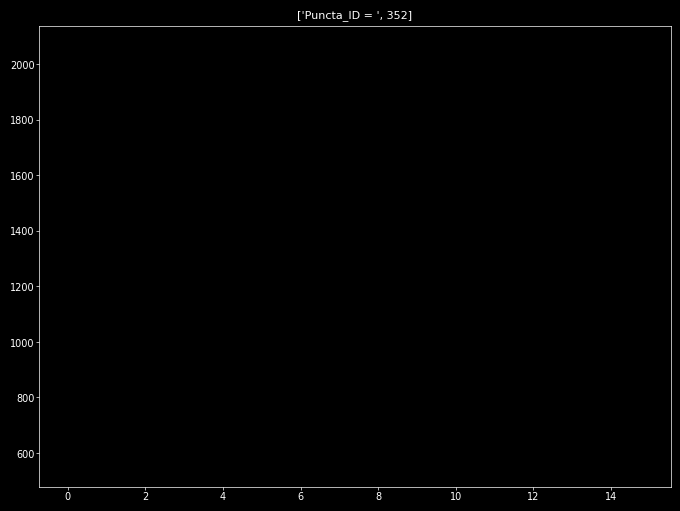

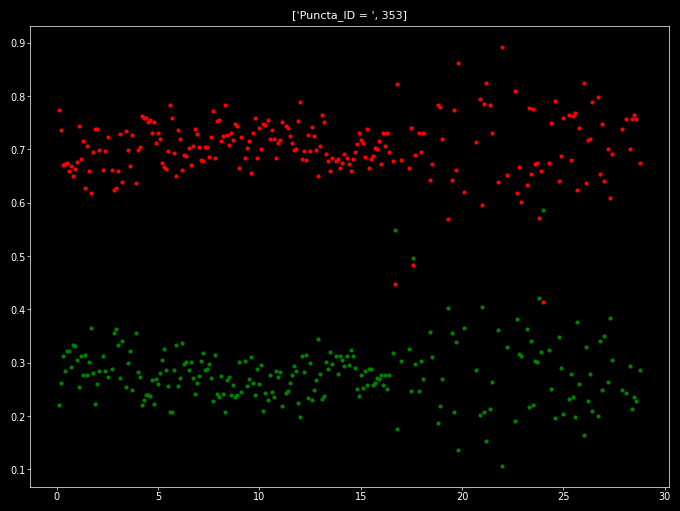

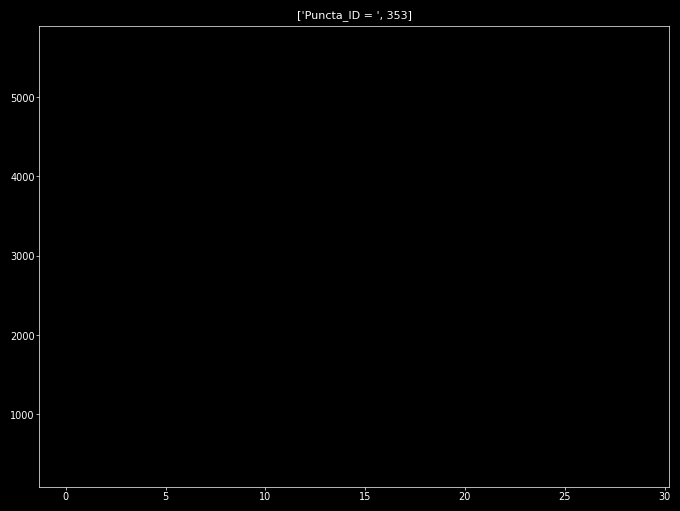

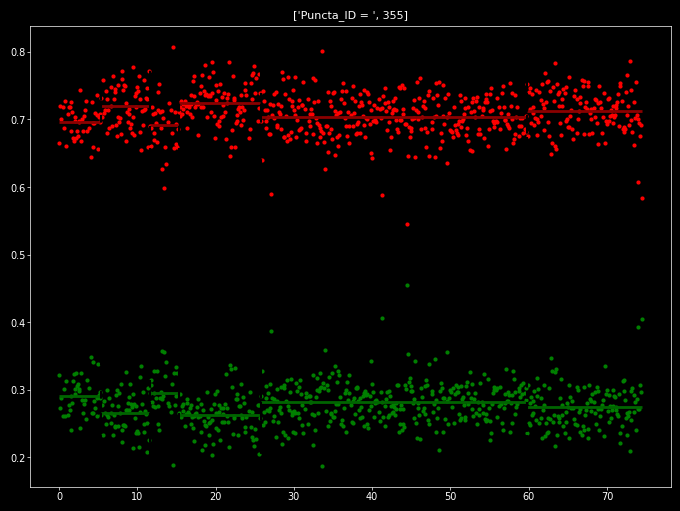

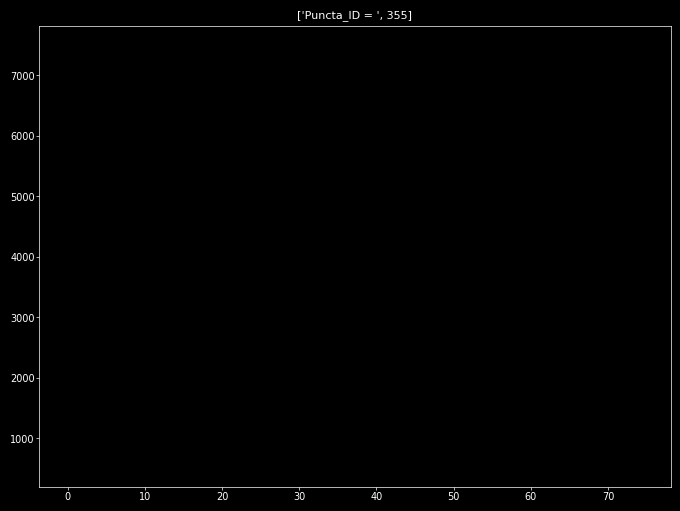

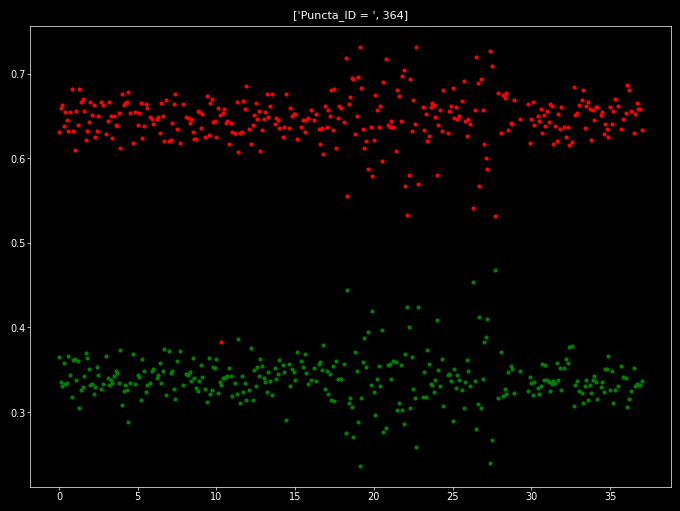

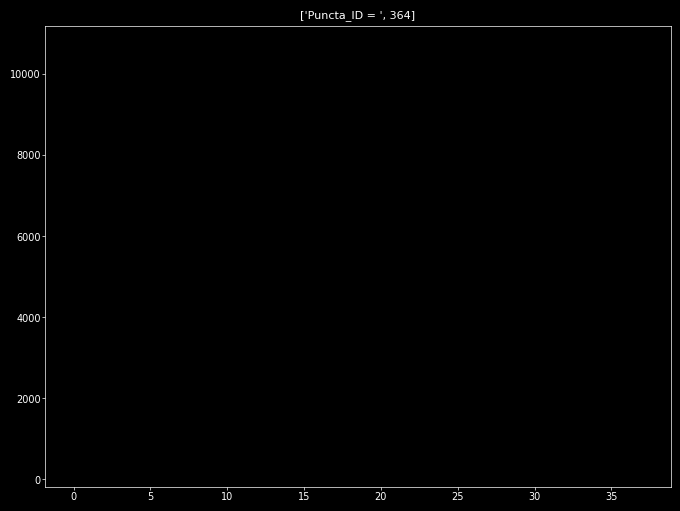

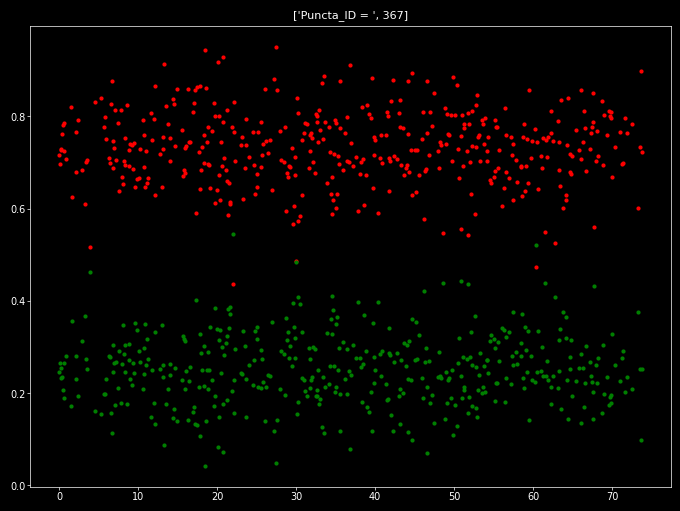

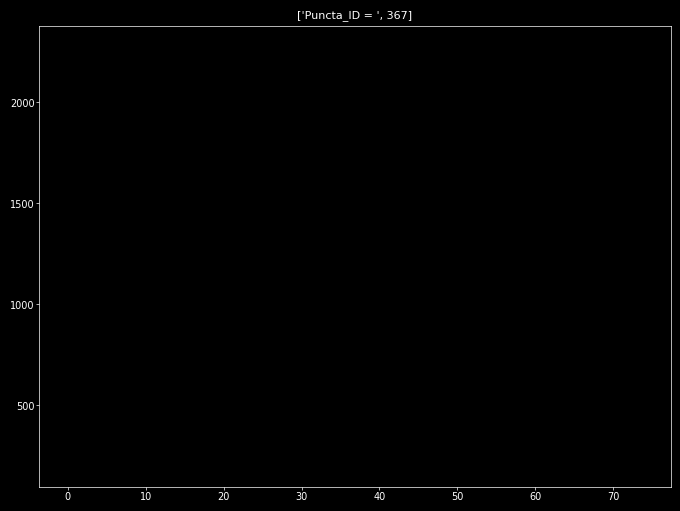

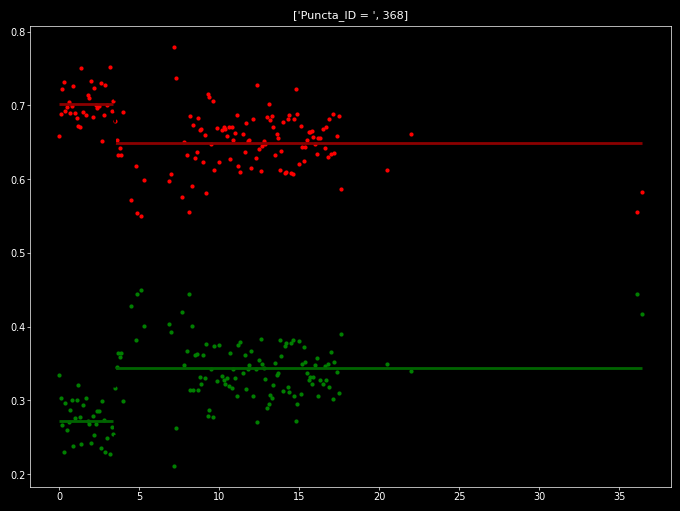

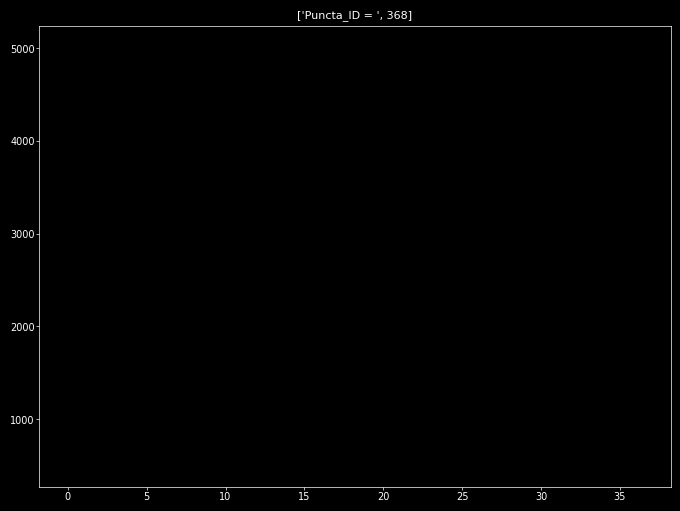

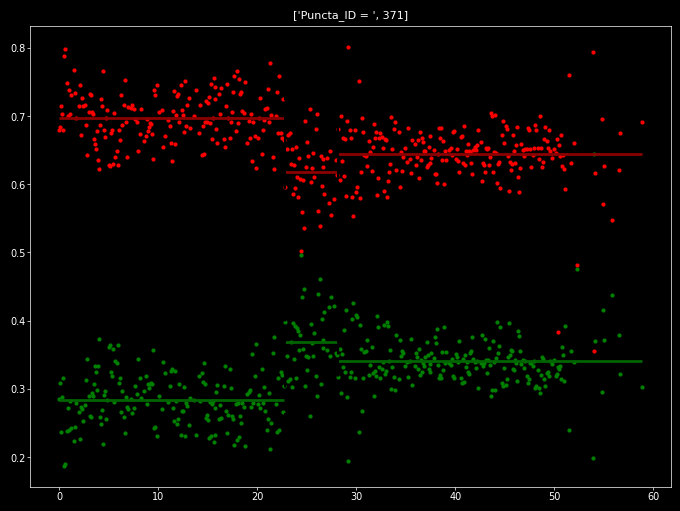

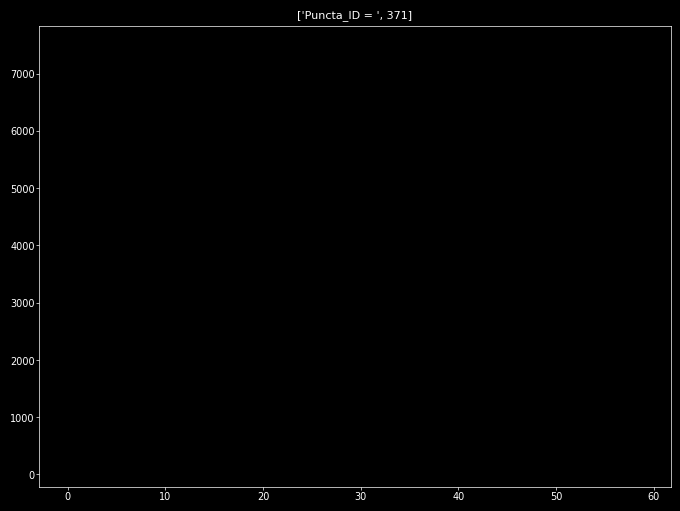

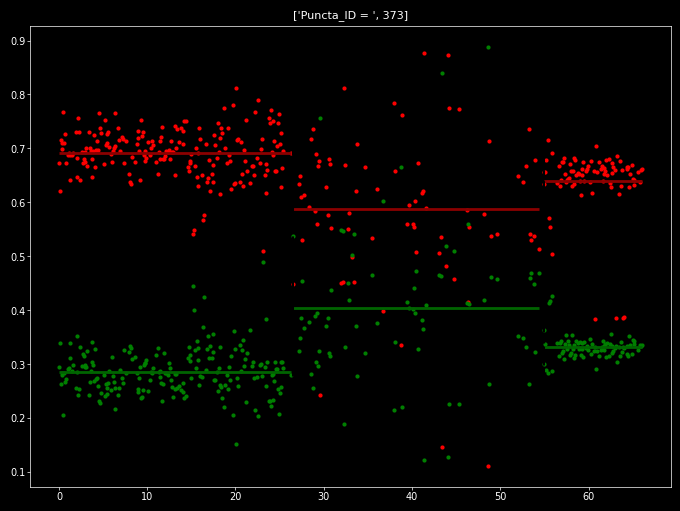

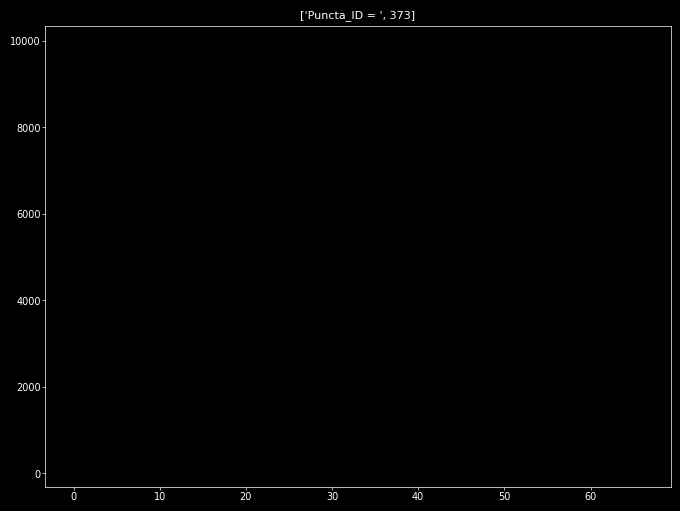

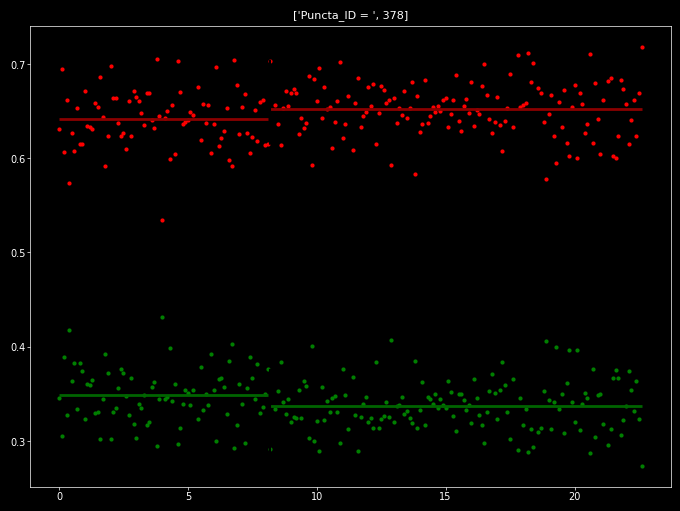

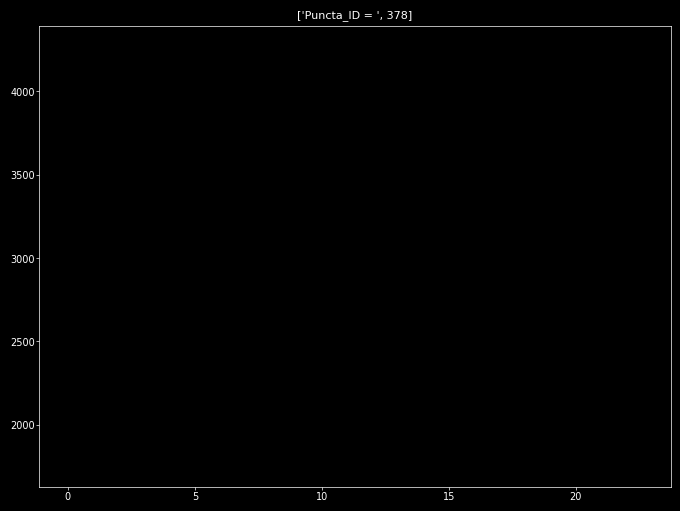

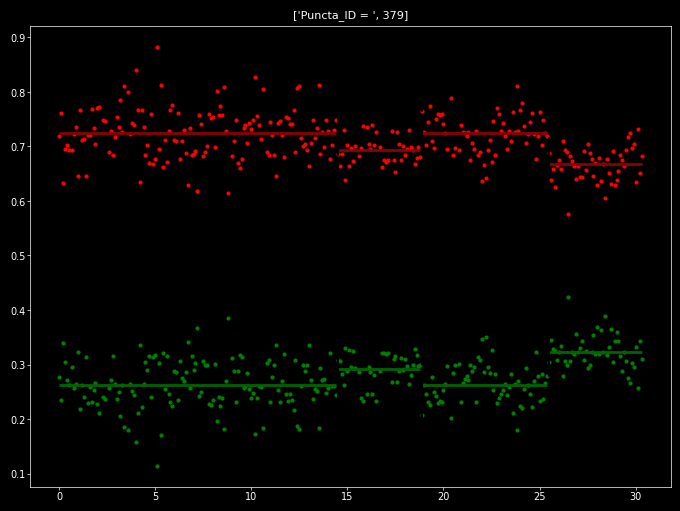

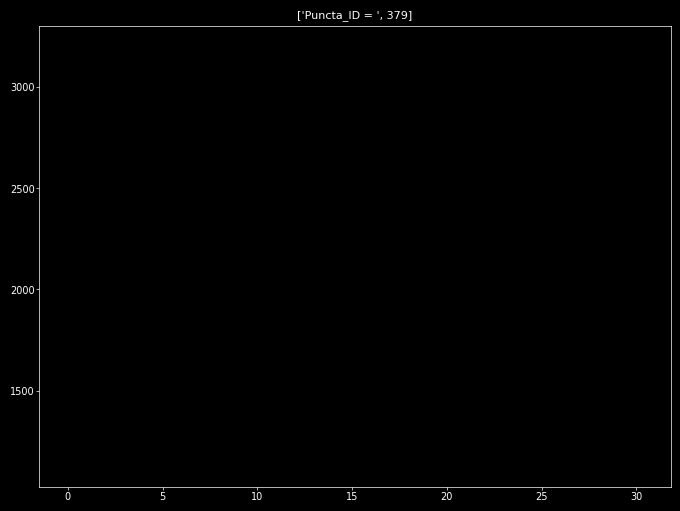

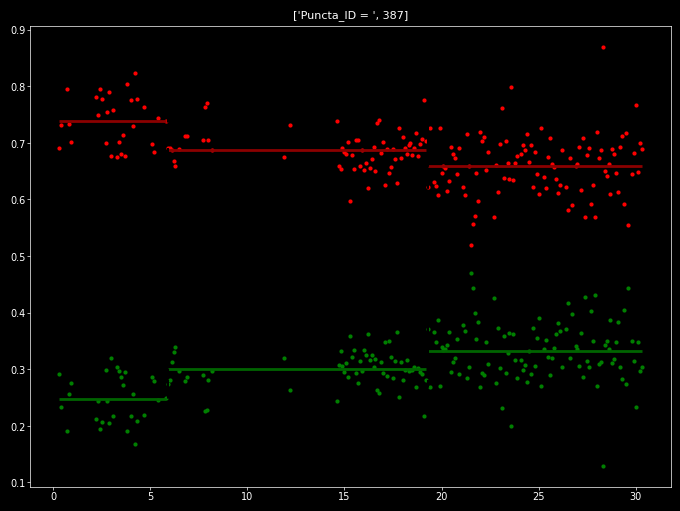

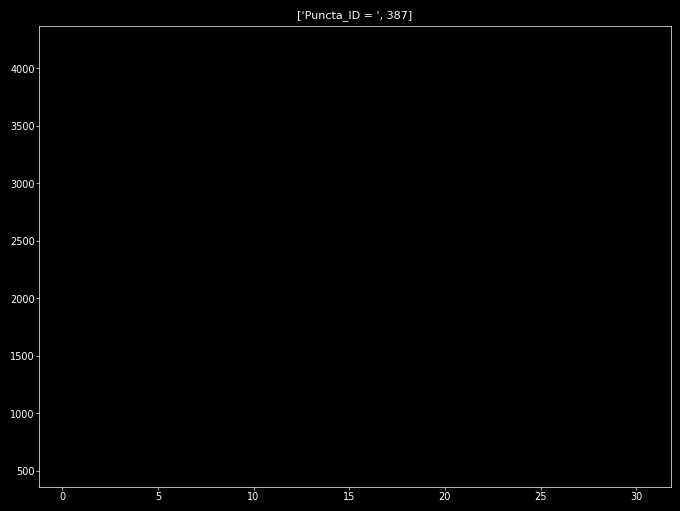

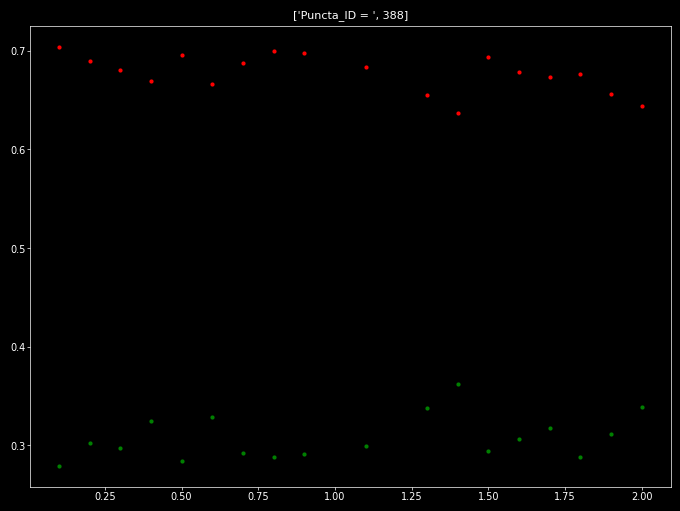

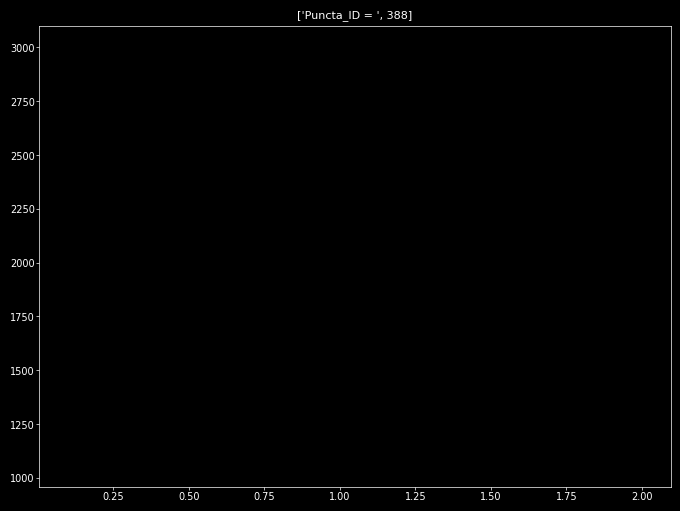

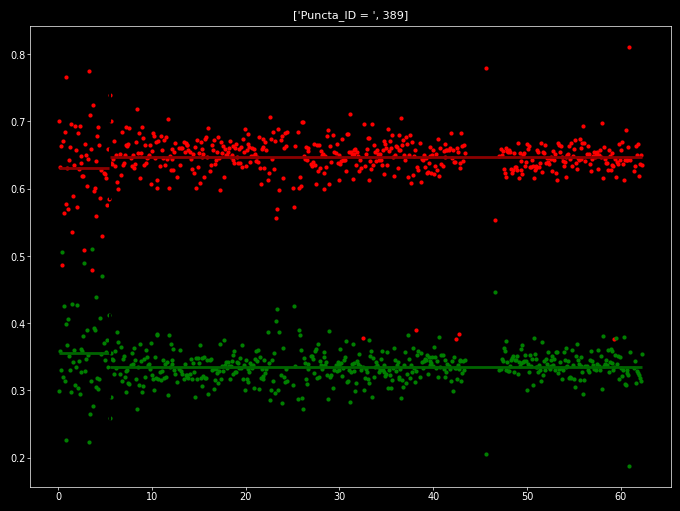

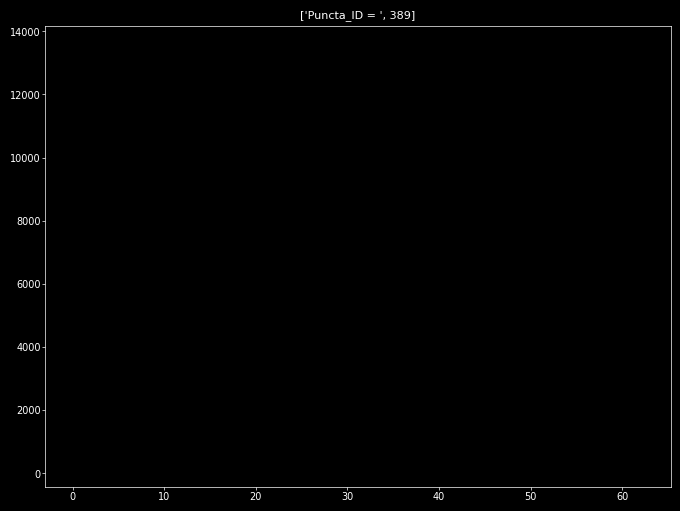

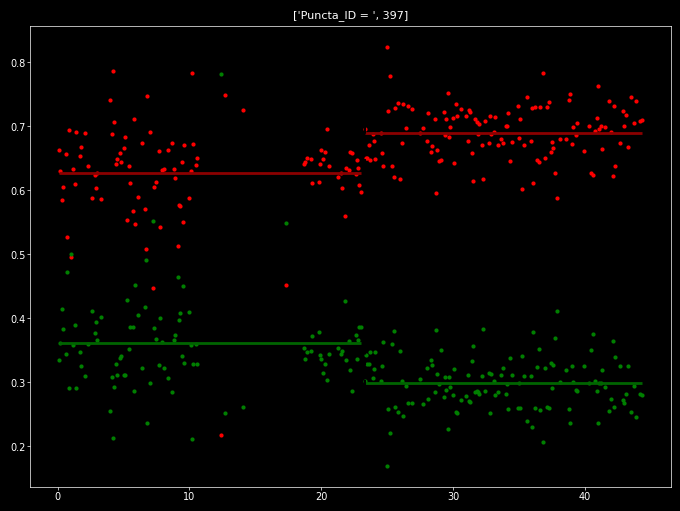

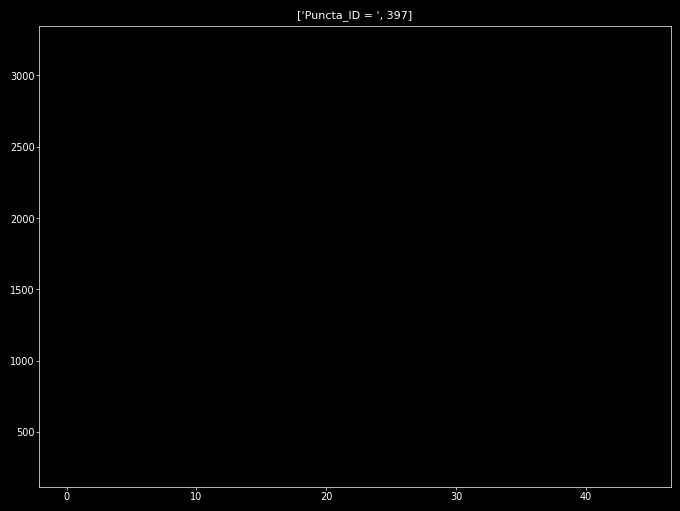

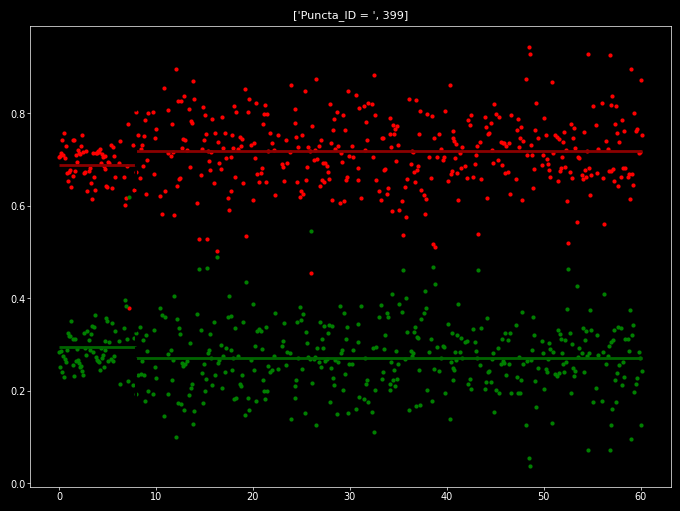

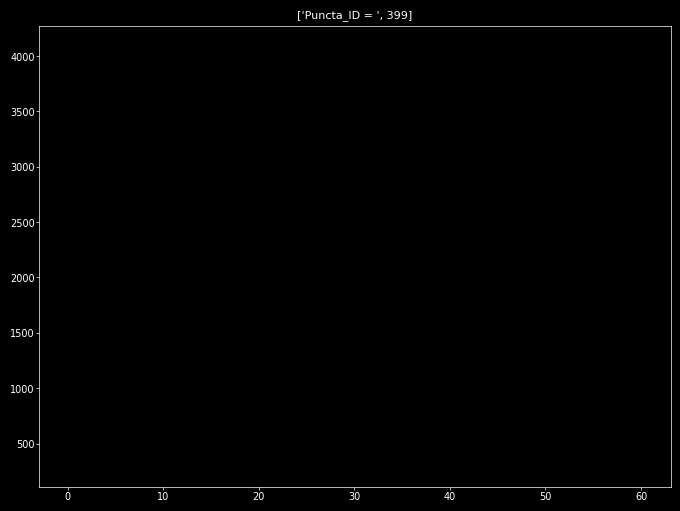

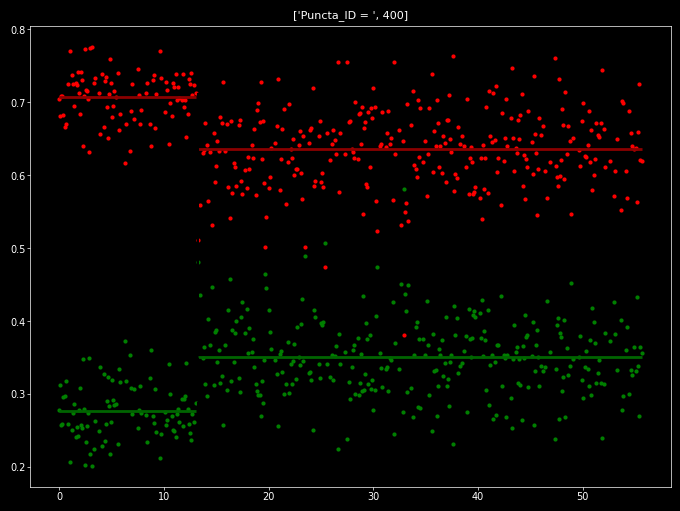

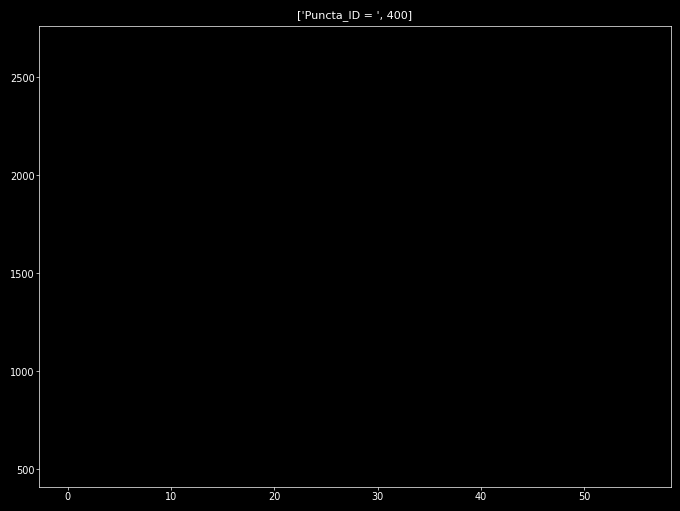

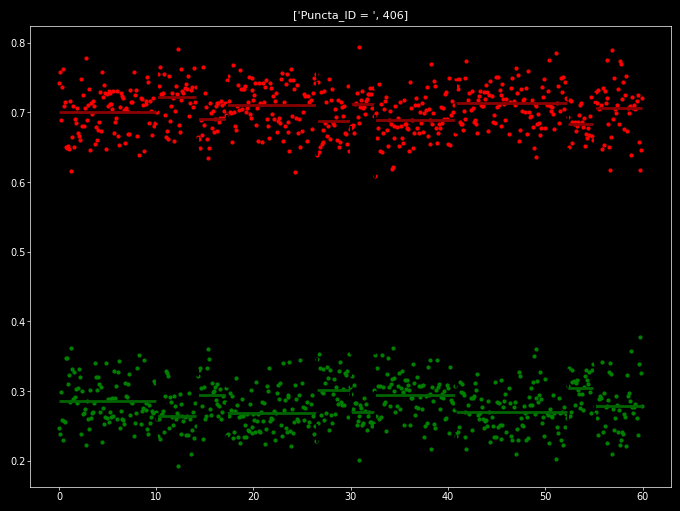

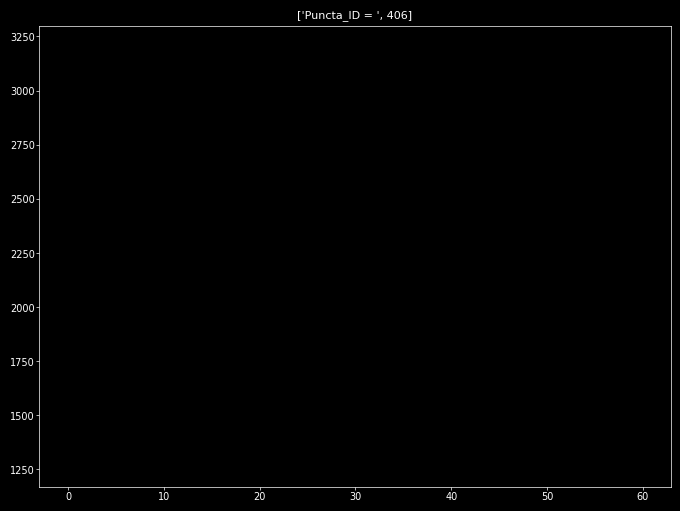

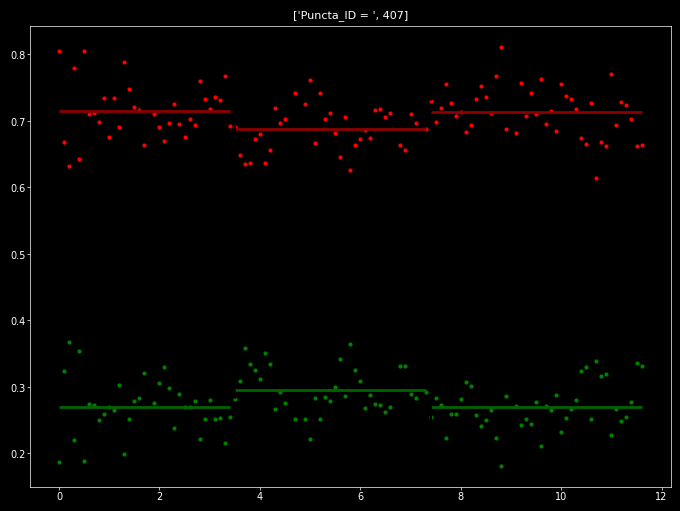

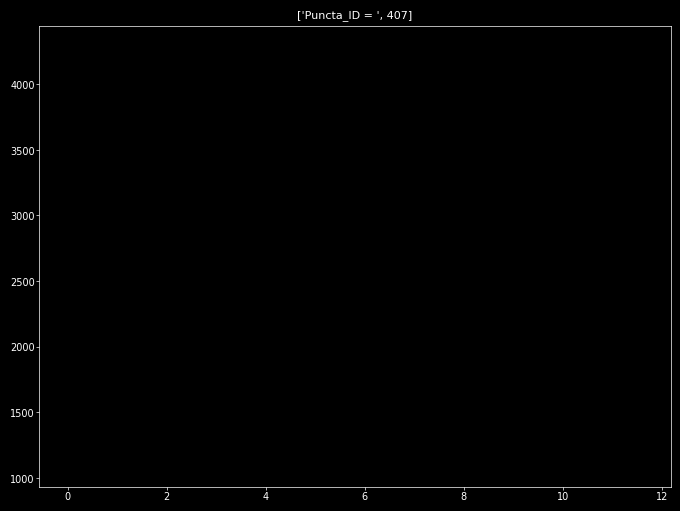

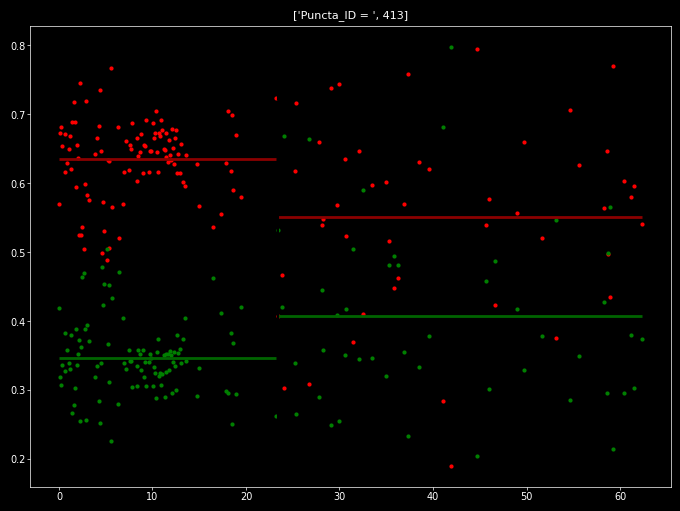

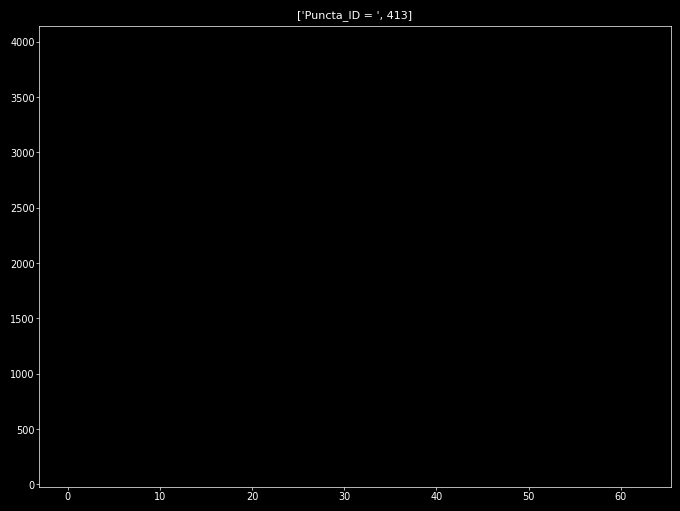

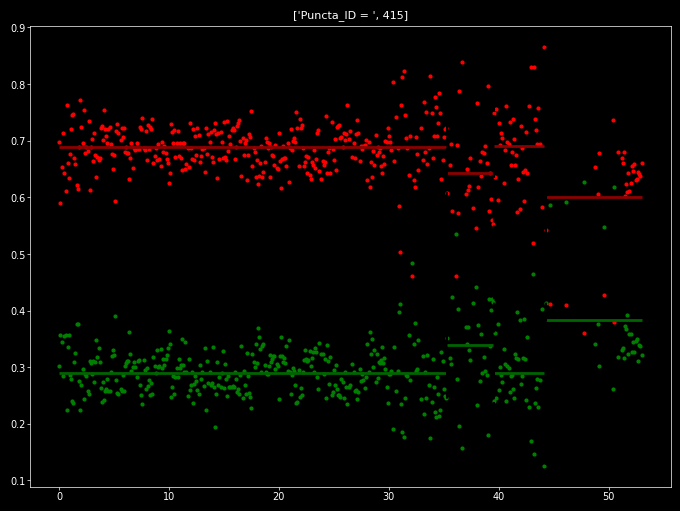

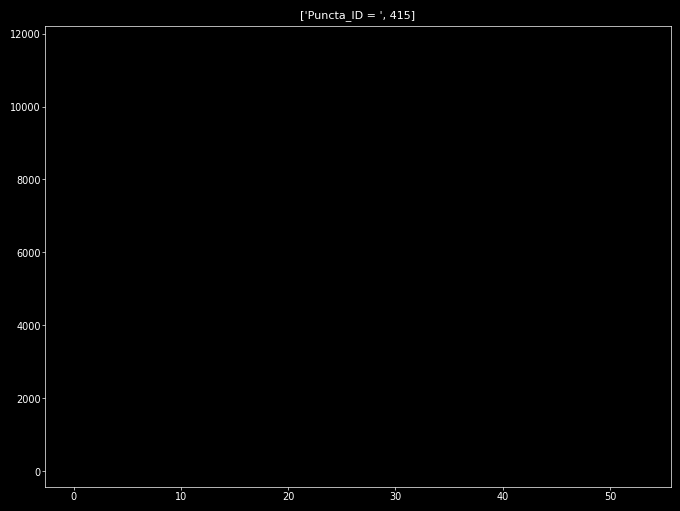

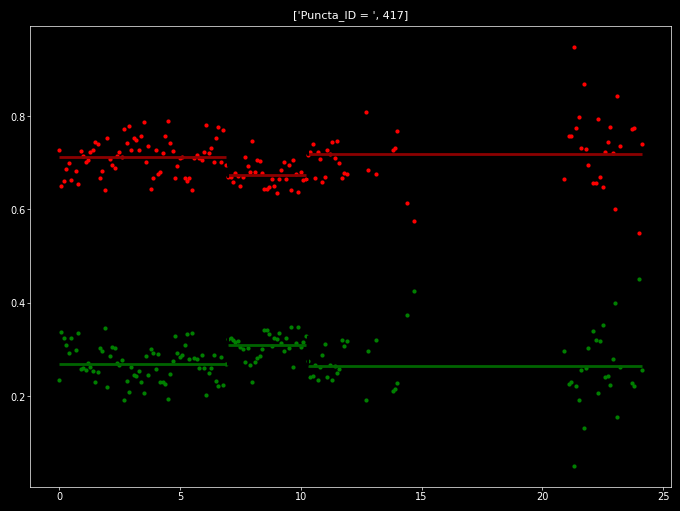

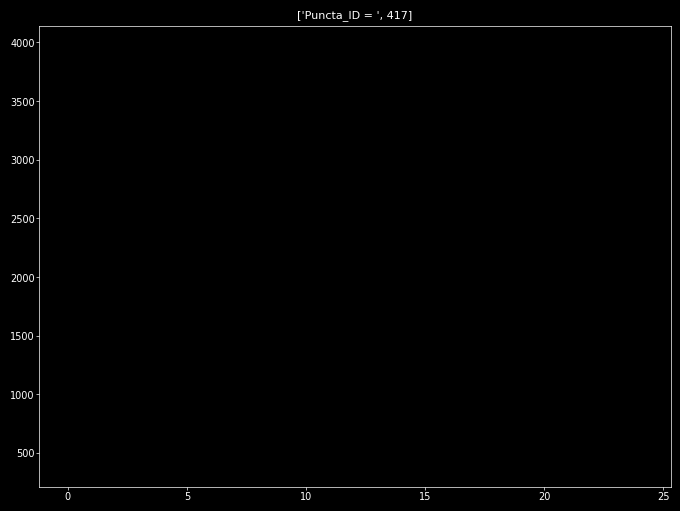

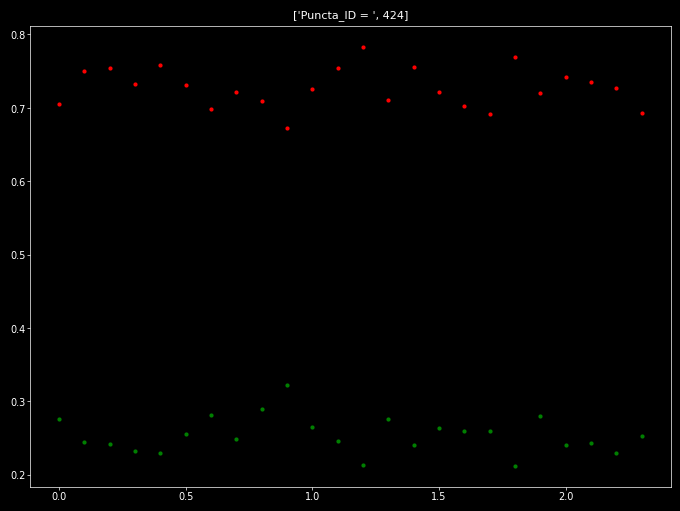

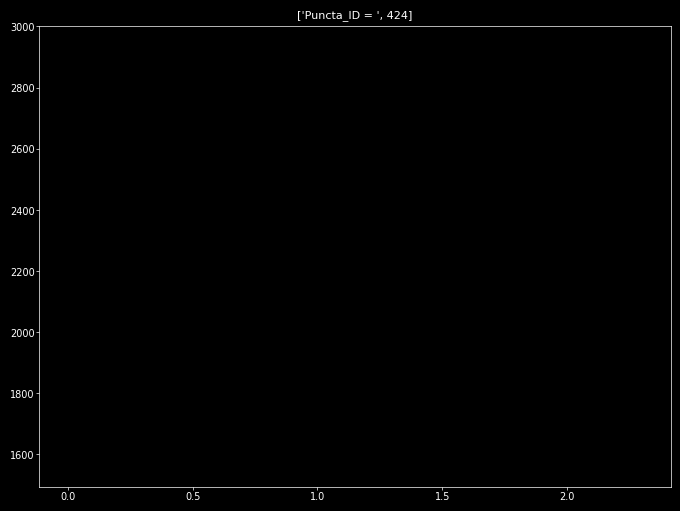

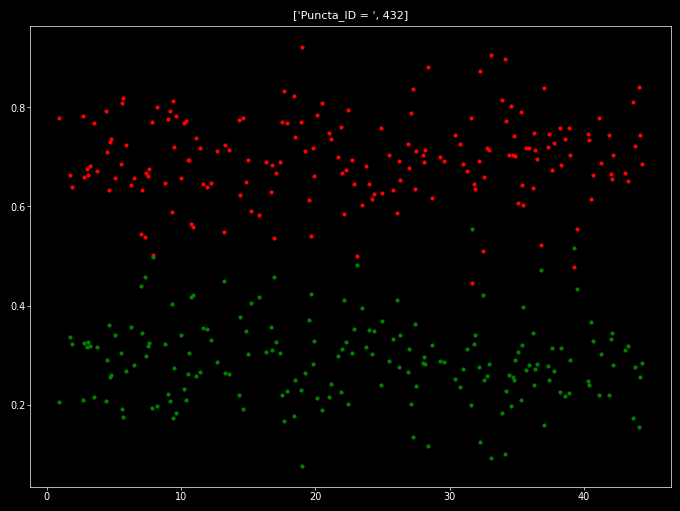

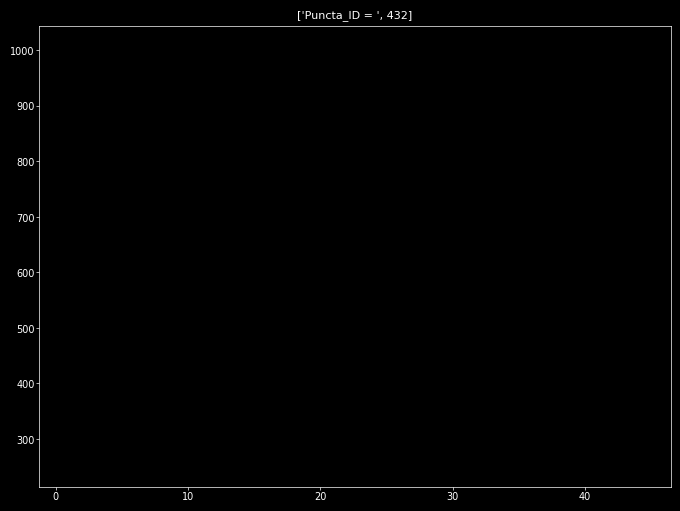

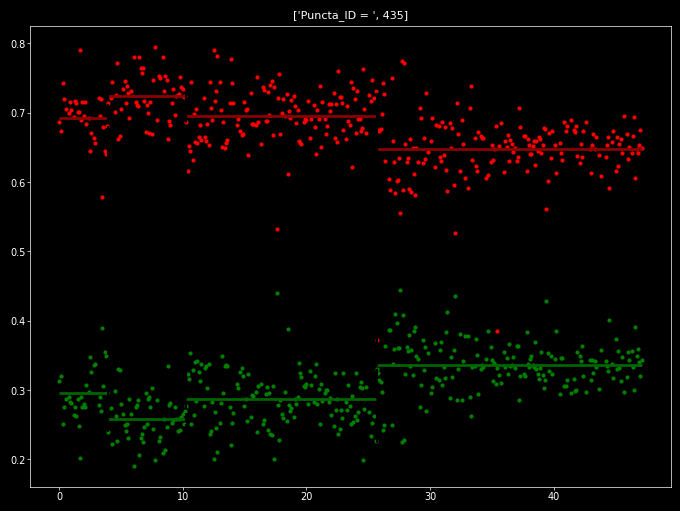

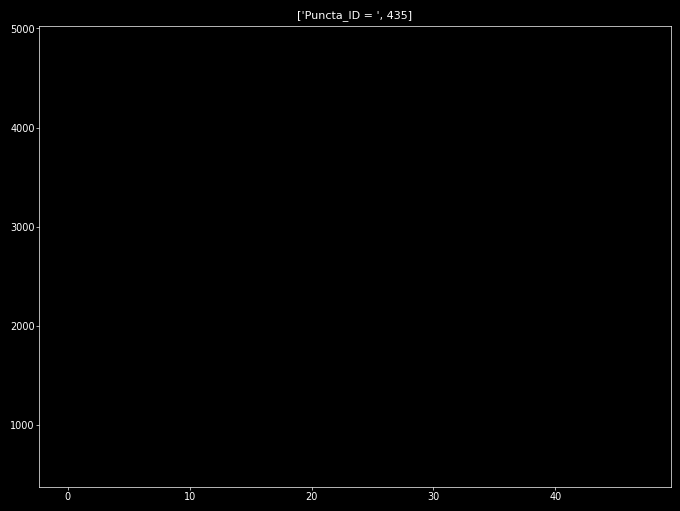

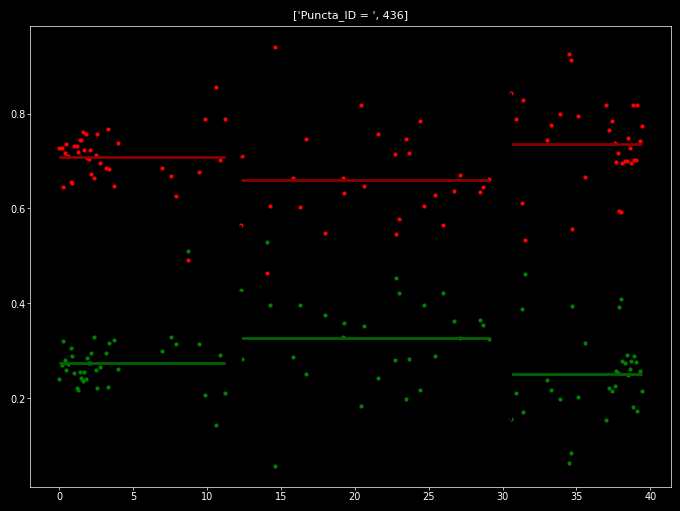

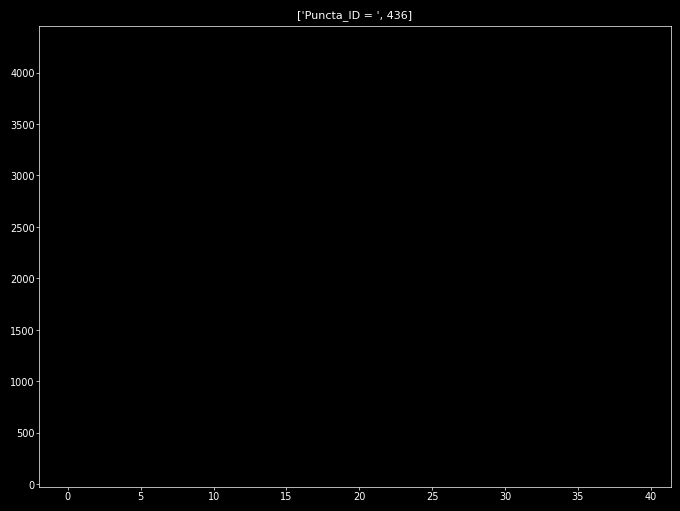

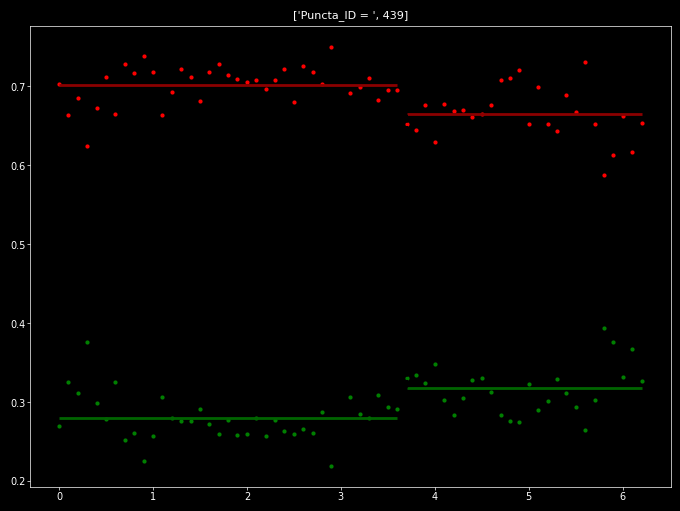

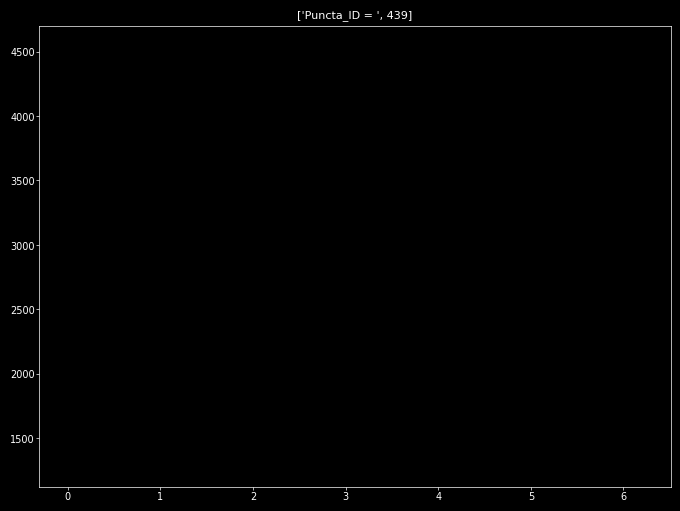

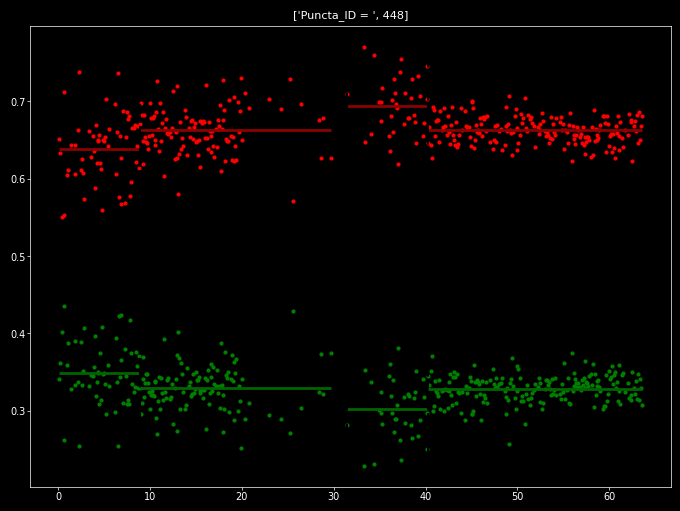

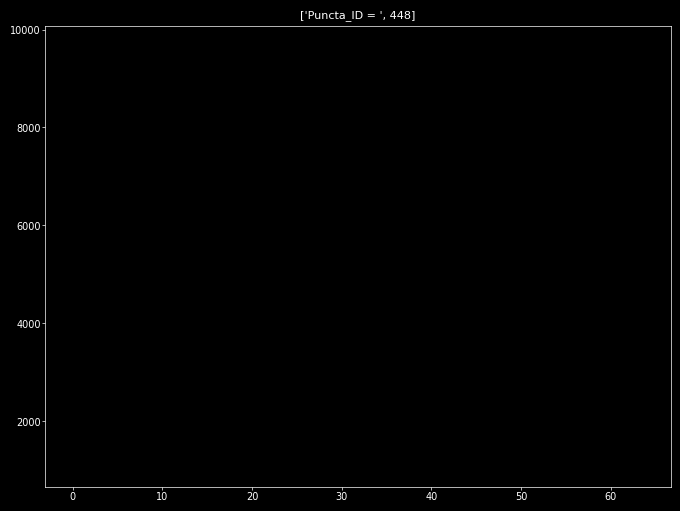

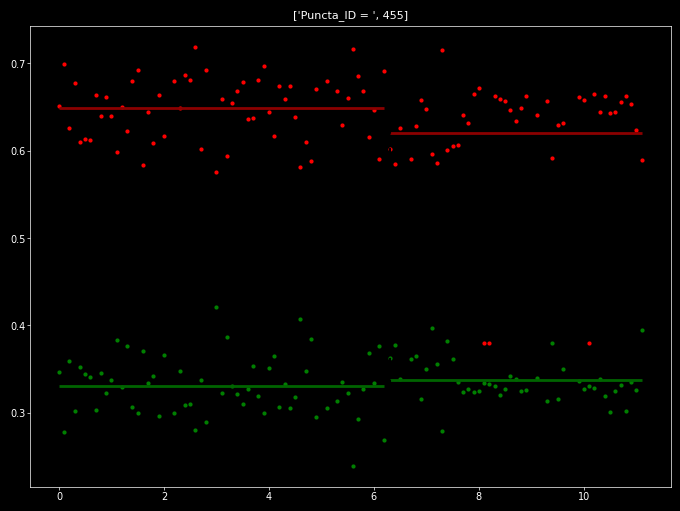

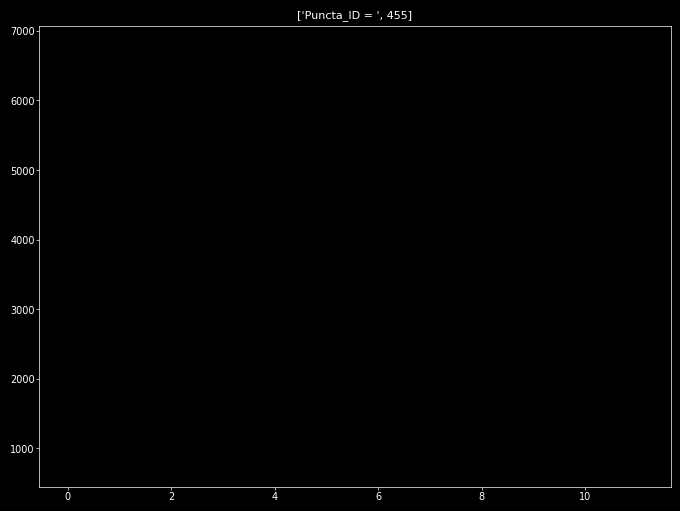

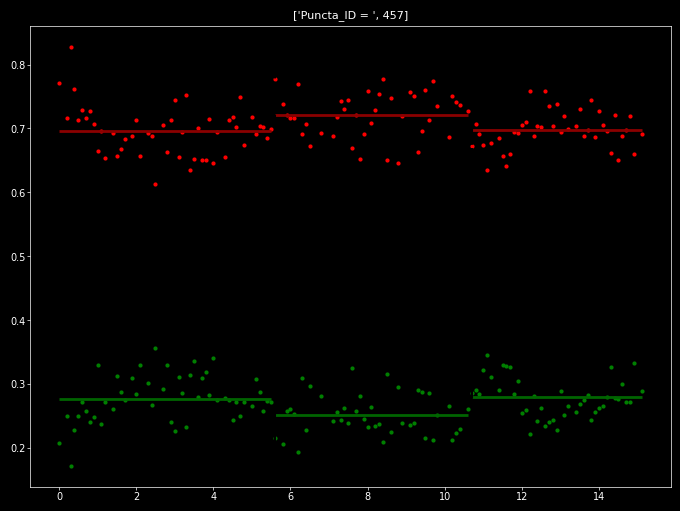

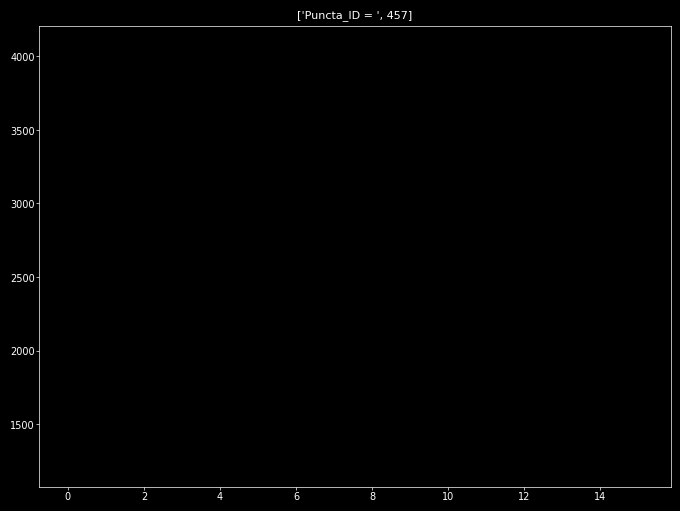

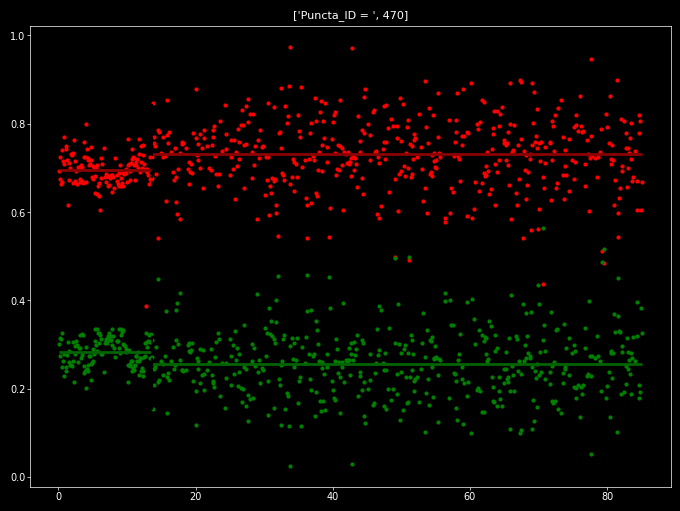

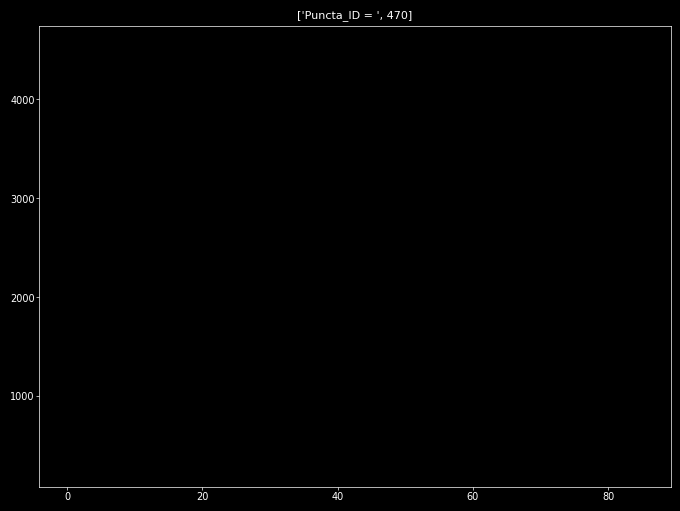

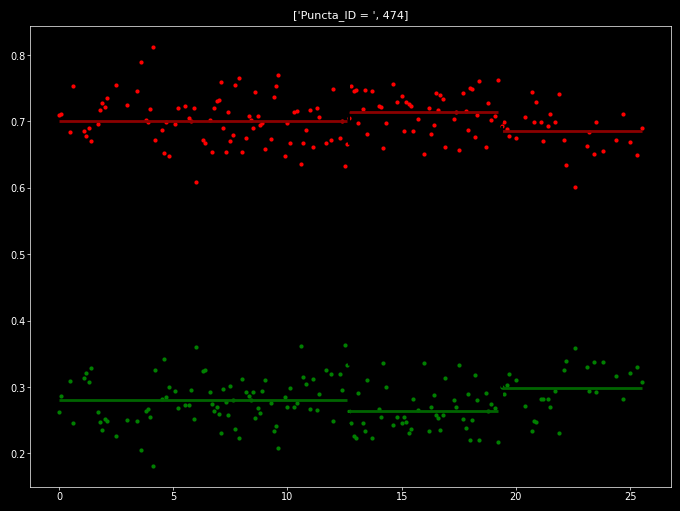

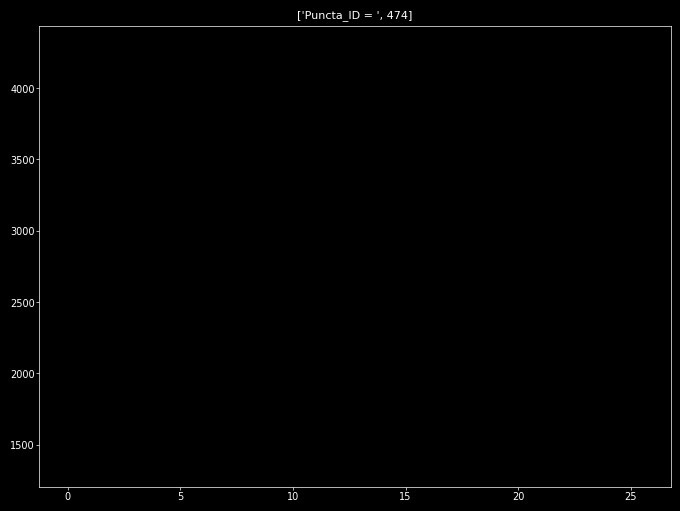

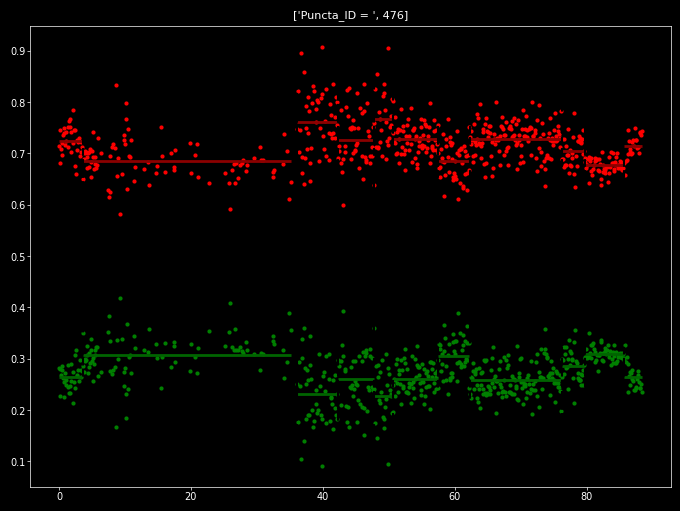

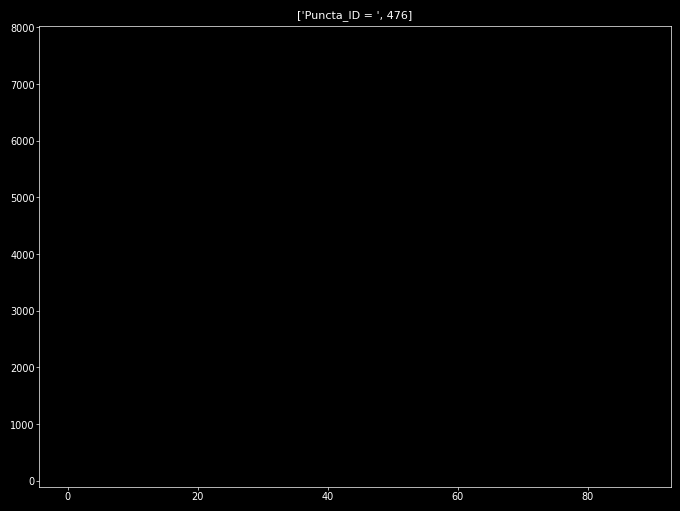

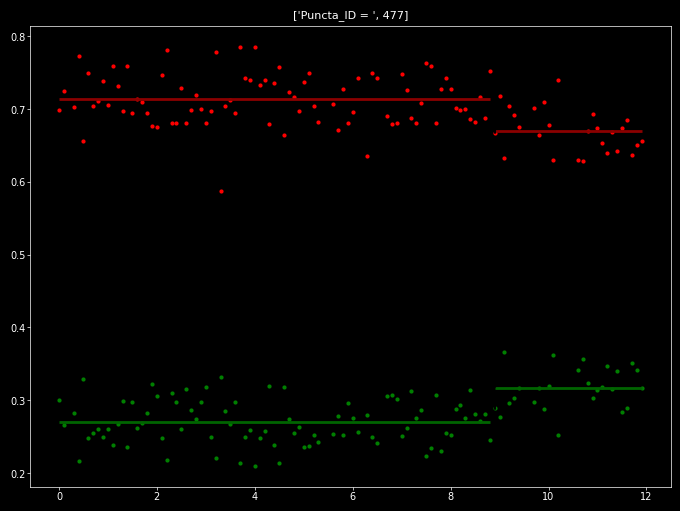

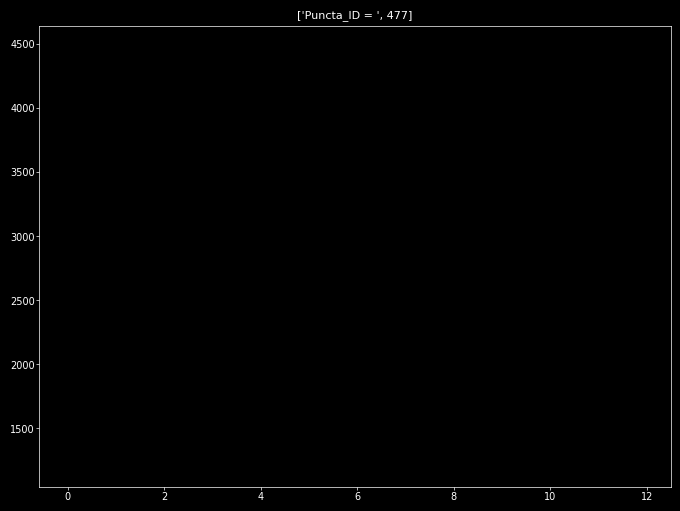

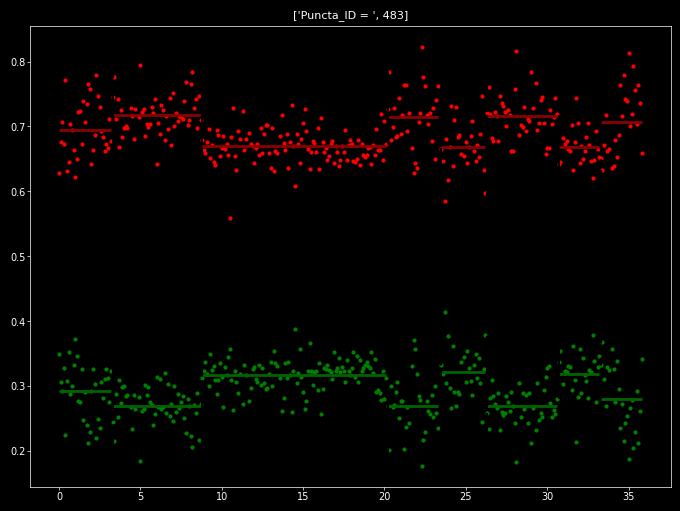

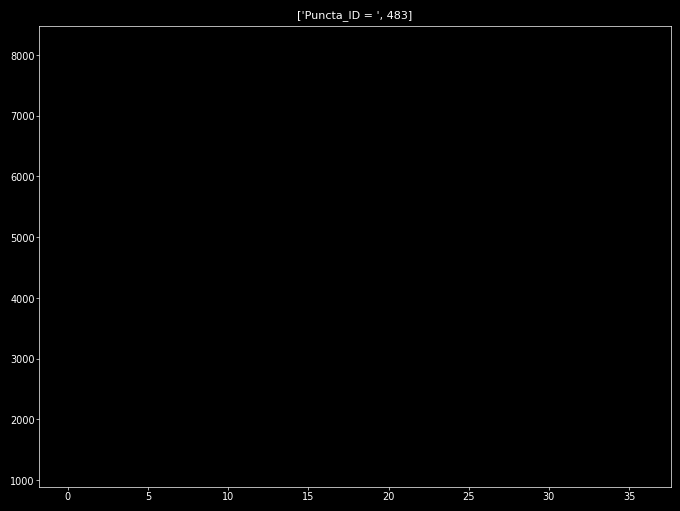

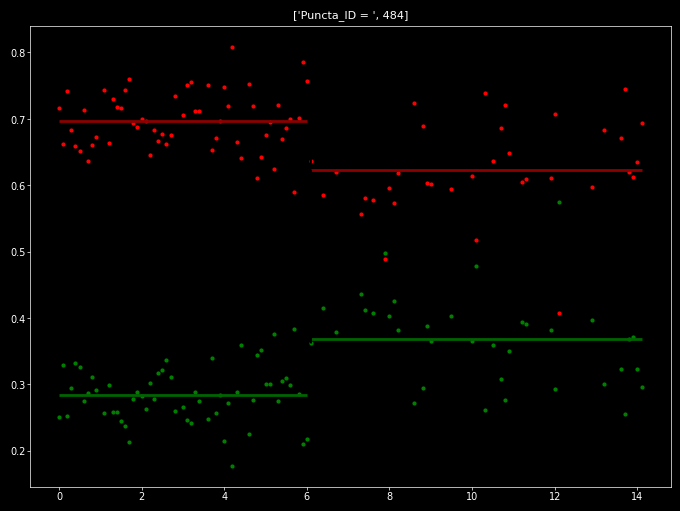

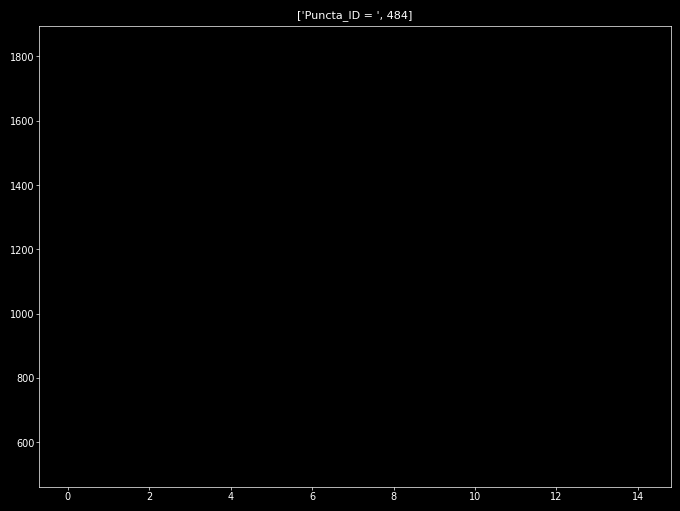

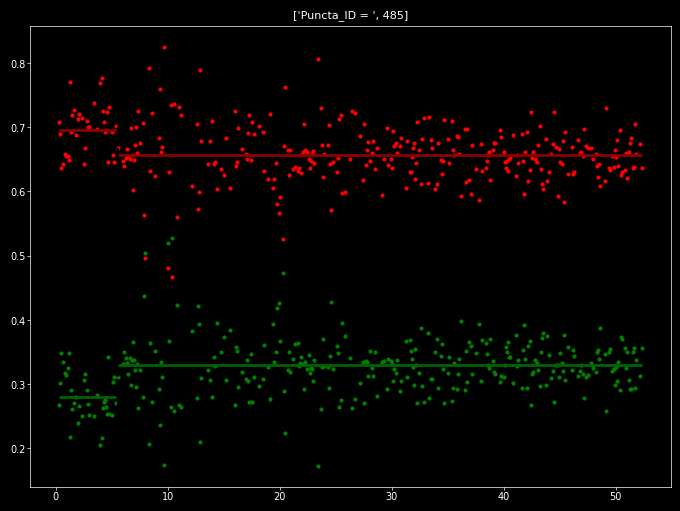

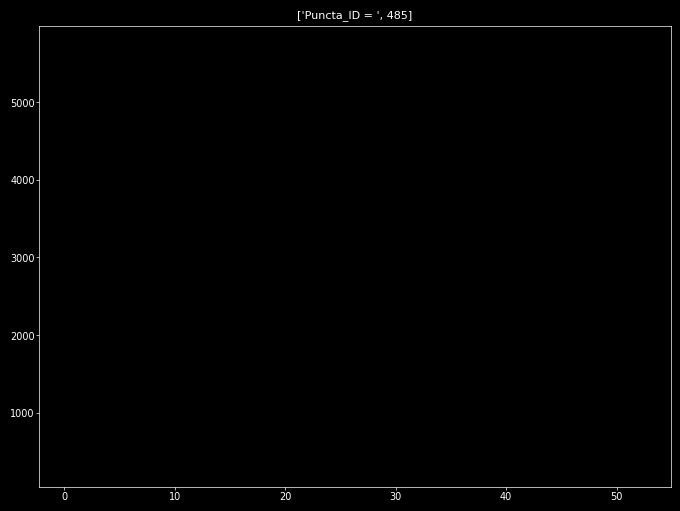

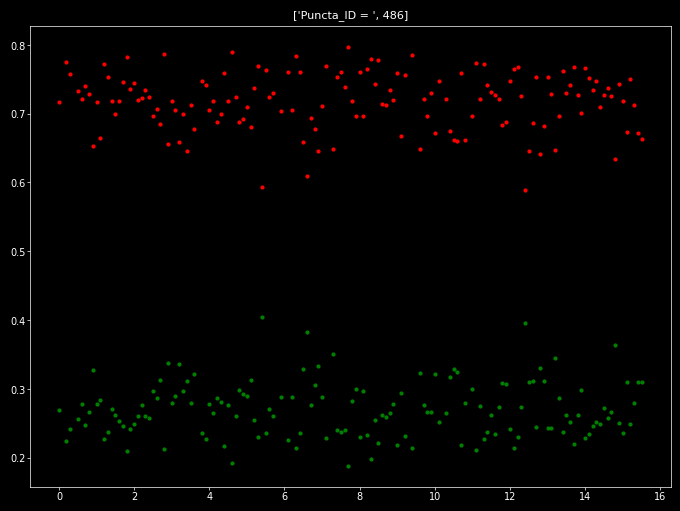

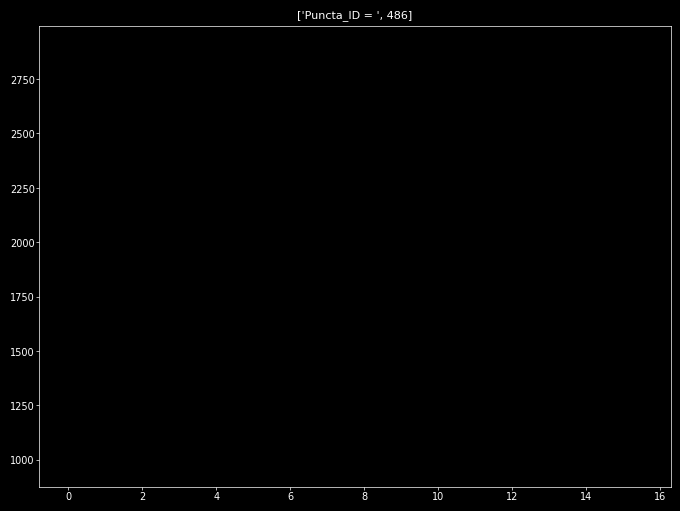

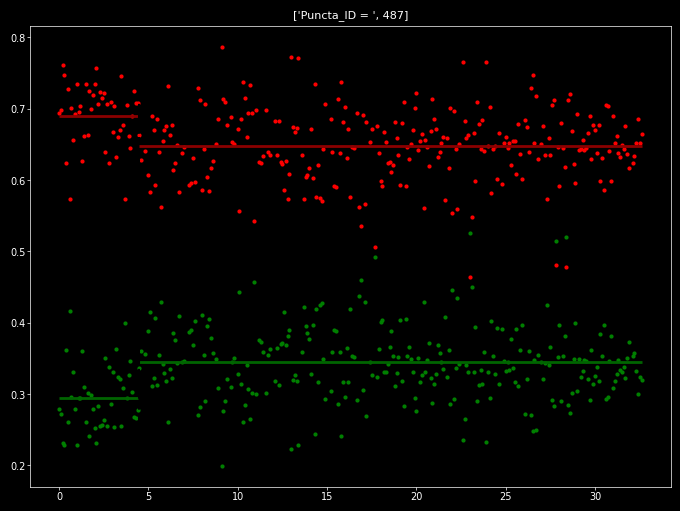

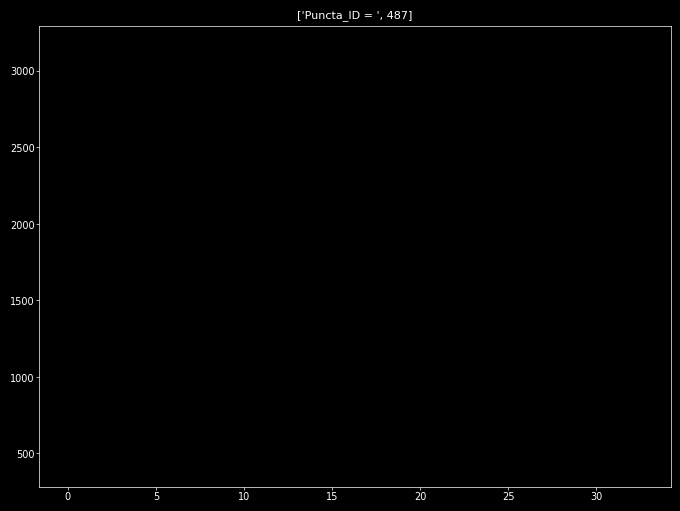

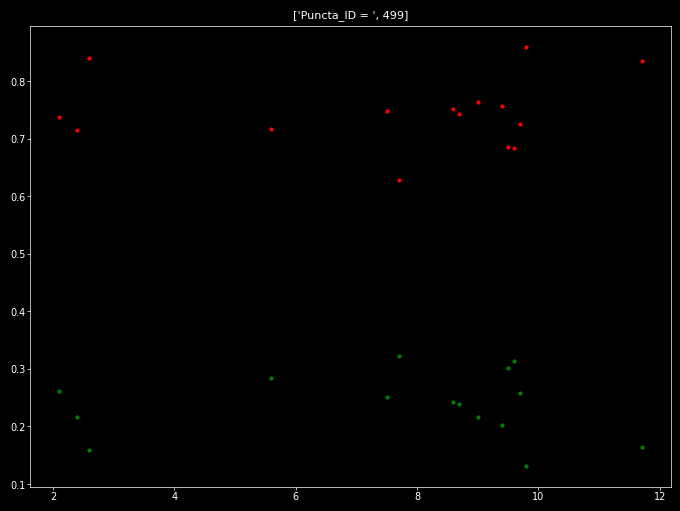

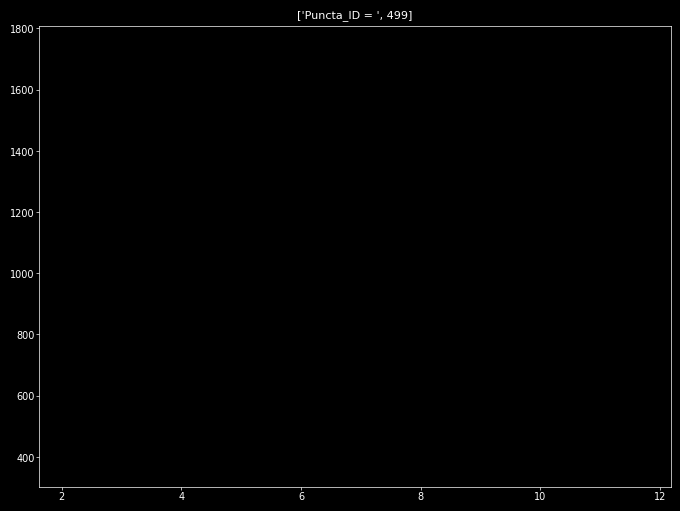

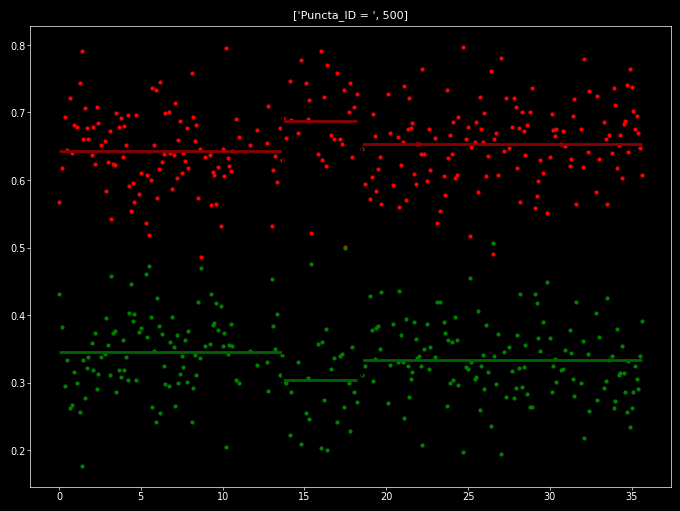

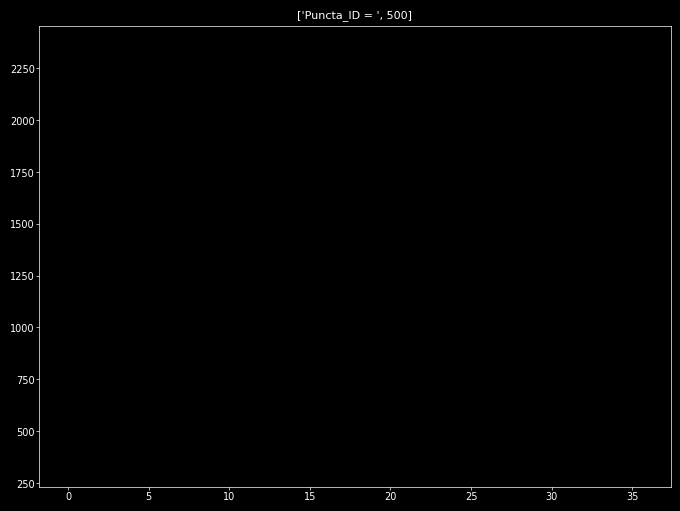

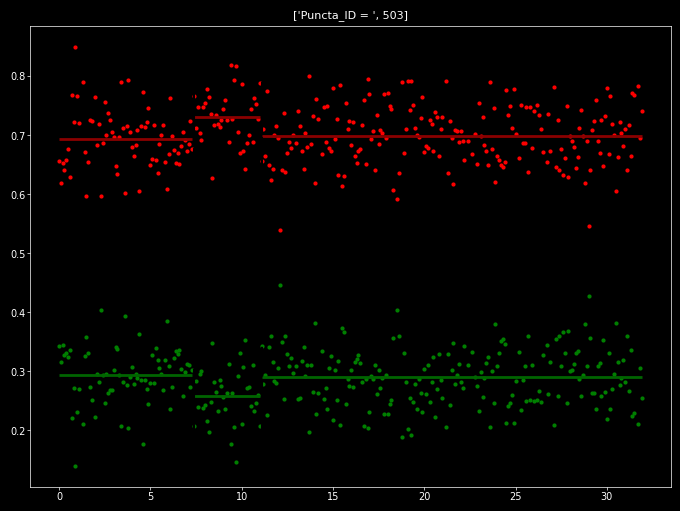

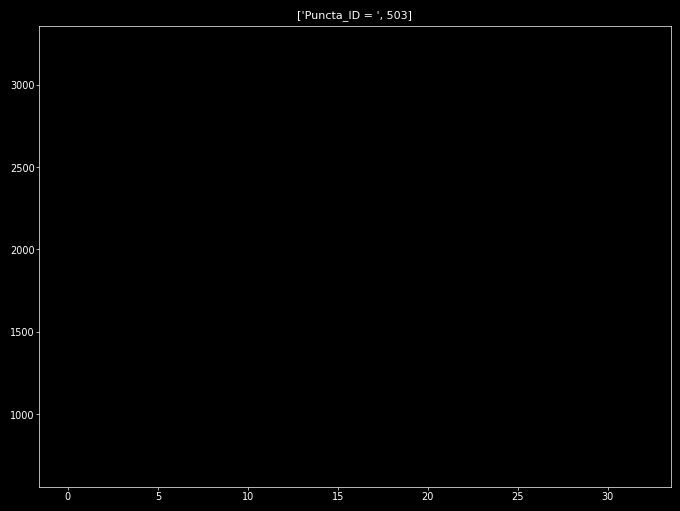

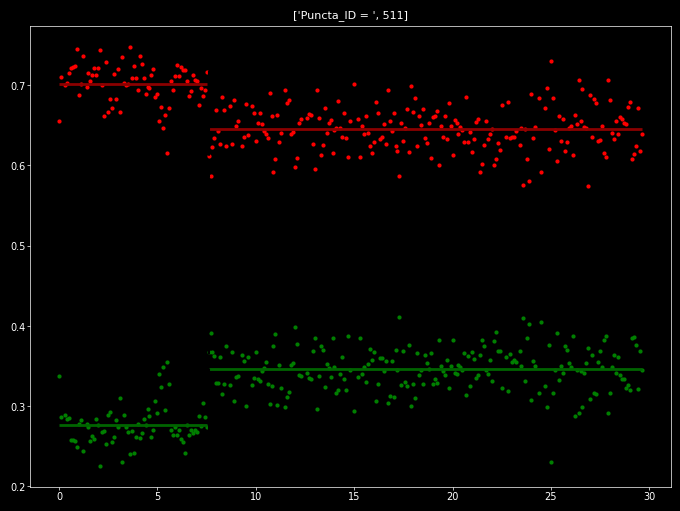

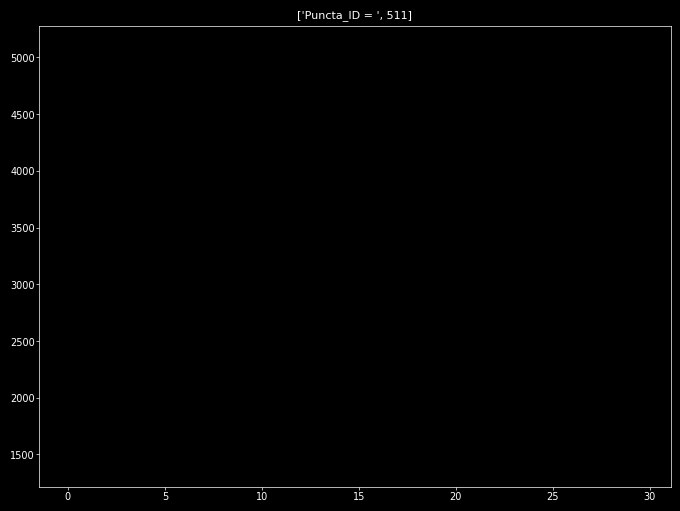

In [21]:
# plot segment means for one punctum, 9, 14,15,20
exposure_time = 0.1
for i in range(ROI_puncta_ID.size):
    pid = ROI_puncta_ID[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]
    
    t = sub['frame'].values * exposure_time
    plt.scatter(t, sub['A_R'], s=4, c='red')
    for _, row in segs.iterrows():
        plt.hlines(row['A_R_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='darkred', lw=2)
    plt.scatter(t, sub['A_G'], s=4, c='green')
    for _, row in segs.iterrows():
        plt.hlines(row['A_G_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='darkgreen', lw=2)
    for _, cp in cps.iterrows():
        plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
    plt.title(['Puncta_ID = ',pid])
    plt.show()
    
    plt.scatter(t, sub['photons'], s=4, c='black')
    for _, cp in cps.iterrows():
        plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
    plt.title(['Puncta_ID = ',pid])

    plt.show()


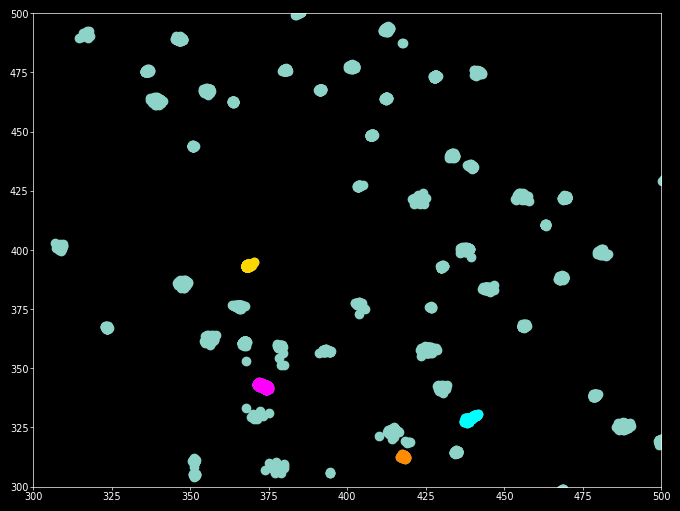

In [22]:
plt.scatter(df_data['xc'],df_data['yc'])
origin =400
ROI = 200 # pixel roi
x_begin = origin-ROI/2
x_end= origin + ROI/2

y_begin = origin-ROI/2
y_end= origin + ROI/2

plt.xlim([x_begin,x_end])
plt.ylim([y_begin,y_end])

ROI_true = (df_data['xc'] > x_begin)*(df_data['xc'] < x_end)*(df_data['yc'] > y_begin)*(df_data['yc'] < y_end)
ROI_df_data = df_data[ROI_true]
select_puncta = [327, 344, 355, 406]
color_select = ['darkorange','cyan','magenta','gold']
for i in range(4):
    sub  = df_data[df_data['puncta_id'] == select_puncta[i]].sort_values('frame')
    plt.scatter(sub['xc'],sub['yc'],c=color_select[i])


In [18]:
raw_image = IO.read_tiff(tiff_files[0])


In [ ]:
[fig, axs] = plotter.one_column_plot(height=5, width=2)
plotter = PlottingFunctions.Plotter(dark_background=True)
plotter.create_image_plot(axs,raw_image[200,:,280:480],cmap='gray')
#plt.xlim([300,500])
#plt.ylim([300,500])
plotter.add_scalebar(axs,69,5000,'lower right')
for i in range(4):
    sub  = df_data[df_data['puncta_id'] == select_puncta[i]].sort_values('frame')
    xc_coord = np.mean(sub['xc']) - 280
    yc_coord = np.mean(sub['yc']) -0
    plt.scatter(xc_coord,yc_coord,edgecolors=color_select[i],s=200,facecolors='none',linewidths=1.5)
#folder_tosave = r'/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
#plt.savefig(os.path.join(folder_tosave, 'SelectPoints.svg'), dpi=600, format='svg')

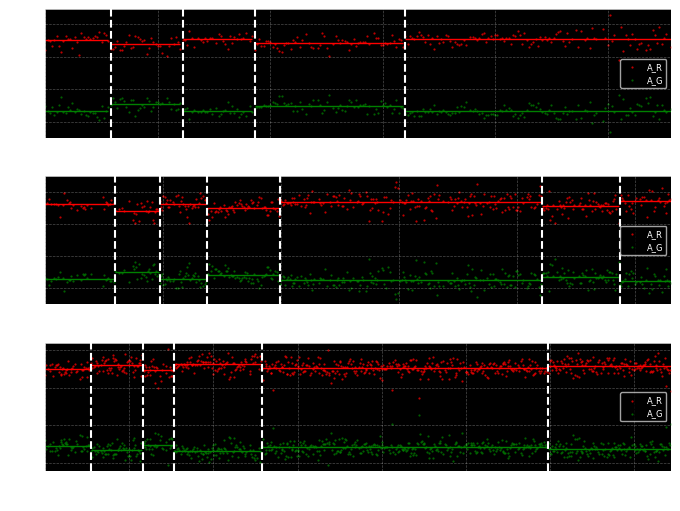

In [26]:
fig, axs = plotter.two_column_plot(nrows=3, heightratio=[1, 1, 1], height=5)
exposure_time = 0.1
for i in range(3):
    pid = select_puncta[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]
    
    t = sub['frame'].values * exposure_time
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_R'], s=2.5, facecolor='red', lw=0, label='A_R',alpha=0.75, xaxislabel='time / s')
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_G'], s=2.5, facecolor='green', lw=0, label='A_G',alpha=0.75, xaxislabel='time / s')
    axs[i].set_xlim([t.min(), t.max()])

    for _, row in segs.iterrows():
        axs[i].hlines(row['A_R_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='red', lw=1)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_G_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='green', lw=1)
    for _, cp in cps.iterrows():
        axs[i].axvline(cp['frame'] * exposure_time, ls='--', color='white', lw=1.5)
    del sub    
folder_tosave = r'/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder_tosave, 'changepoints.svg'), dpi=600, format='svg')

In [ ]:
changepoint_files[24]

In [27]:
dfs = []
cp_dfs = []
seg_dfs = []
for i in range(24) : 
    [df_data, cp_df, seg_df] = load_changepoint_analysis(changepoint_files[i])
    dfs.append(df_data)
    cp_dfs.append(cp_df)
    seg_dfs.append(seg_df)

final_df_data = pd.concat(dfs)
final_cp_df = pd.concat(cp_dfs)
final_seg_df = pd.concat(seg_dfs)




In [28]:
[E_all,residuals_all] = RGB_to_E_Cy3Cy5_cp(final_seg_df)

['changpoints = ', 26891]
['N Molecules = ', 18479]


/tmp/ipykernel_2450571/1140760277.py:1: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=True)


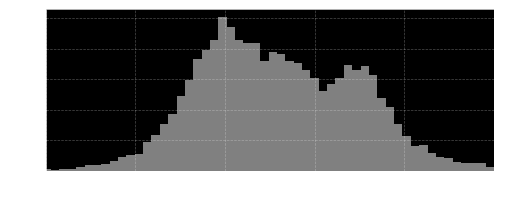

In [34]:
plotter = PlottingFunctions.Plotter(dark_background=True)

[fig, axs] = plotter.one_column_plot(height=2, width=5)
axs = plotter.histogram_plot(axs,E_all,bins=601,xlim=[0,1])
print(['changpoints = ',E_all.size])
print(['N Molecules = ',final_cp_df.shape[0]])
#folder_tosave = r'/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
#plt.savefig(os.path.join(folder_tosave, 'FRET_efficiency.svg'), dpi=600, format='svg')

In [ ]:
final_cp_df

In [ ]:
final_seg_df

In [ ]:
[df_data, cp_df, seg_df] = load_changepoint_analysis(changepoint_files[0])

In [ ]:
plotter = PlottingFunctions.Plotter(dark_background=False)

fig, axs = plotter.two_column_plot(nrows=4, heightratio=[1, 1, 1, 1])
select_puncta = [327, 344, 355, 406]

exposure_time = 0.1
for i in range(4):
    pid = select_puncta[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]
    
    t = sub['frame'].values * exposure_time
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_R'], s=5, facecolor='red', lw=0, label='A_R',alpha=0.75)
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_G'], s=5, facecolor='green', lw=0, label='A_G',alpha=0.75)
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_B'], s=5, facecolor='blue', lw=0, label='A_B',alpha=0.75)

    for _, row in segs.iterrows():
        axs[i].hlines(row['A_R_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='red', lw=2)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_G_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='green', lw=2)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_B_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='blue', lw=2)
    for _, cp in cps.iterrows():
        axs[i].axvline(cp['frame'] * exposure_time, ls='--', color='white')
    del sub    
folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
plt.savefig(os.path.join(folder_tosave, 'changepoints.svg'), dpi=600, format='svg')